In [2]:
from sklearn.cluster import KMeans
import numpy as np
import h5py
import csv
import math
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.decomposition import PCA
from matplotlib import style
from scipy.ndimage import gaussian_filter
from scipy.ndimage import gaussian_filter1d
from scipy.signal import savgol_filter
from scipy.interpolate import interp1d
from scipy.interpolate import splrep, BSpline
import matplotlib.cm as cm

from sklearn import datasets
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
#import umap
#import umap.umap_ as umap
import pandas as pd
import seaborn as sns
import copy
from scipy.stats import ranksums
from scipy.stats import ks_2samp
import warnings
from matplotlib import style
import matplotlib.pyplot as plt
import Functions.UnifyWormsFun as UNF
import importlib
# Suppress all warnings
warnings.filterwarnings("ignore")

In [3]:
Directory = '/Data/All_Data/All_correspondence/'

Address1 = [Directory +'W0_full_data_0328.csv']
Address2 = [Directory +'W1_full_data_0401.csv']
Address3 = [Directory +'W2_full_data_0511.csv']
Address4 = [Directory +'W3_full_data_0807_first.csv']
Address5 = [Directory +'W4_full_data_0807_second.csv']
Address6 = [Directory +'W5_full_data_0917.csv']
Address7 = [Directory + 'W6_Index_data_0920.csv']
Address8 = [Directory + 'W7_data_RIM_0917.csv']
Address9 = [Directory + 'W8_data_AVA_0319.csv']

Directory2 = '/Data/All_Data/All_point_coord/'
Address1_loc = [Directory2 + 'W0_body_part_time_course_corrected_0328.csv']
Address2_loc = [Directory2 + 'W1_body_part_time_course_corrected_0401.csv']
Address3_loc = [Directory2 + 'W2_body_part_time_course_corrected_0511.csv']
Address4_loc = [Directory2 + 'W3_body_part_time_course_corrected_0807_first.csv']
Address5_loc = [Directory2 + 'W4_body_part_time_course_corrected_0807_second.csv']
Address6_loc = [Directory2 + 'W5_body_part_time_course_corrected_0917.csv']
Address7_loc = [Directory2 + 'W6_CollectedData_Mahsa12800_ext_body_part_time_course_corrected_Sep20.csv']
Address8_loc = [Directory2 + 'W7_CollectedData_Mahsa_ext_body_part_time_course_corrected_RIM.csv']
Address9_loc = [Directory2 + 'W8_CollectedData_Mahsa_ext_body_part_time_course_corrected_AVA.csv']


Directoryh5 = '/Data/All_Data/All_activity1/'
neur_addr1 = Directoryh5 + 'W0_Activity0328_NewNeuritesMean.h5'
neur_addr2 = Directoryh5 + 'W1_Activity0401_NewNeuritesMean.h5'
neur_addr3 = Directoryh5 + 'W2_Activity0511_MoreNeuritesMean.h5'
neur_addr4 = Directoryh5 + 'W3_Activity0807W1_moreNeu.h5'#'Activity_manualCorrectionMost2.h5'
neur_addr5 = Directoryh5 + 'W4_Activity0807W2_MoreNeuritesSub.h5'#'Activity0807sec_allManualcorrect2.h5'
neur_addr6 = Directoryh5 + 'W5_SJR16_0917_Activity0.h5'
neur_addr7 = Directoryh5 + 'W6_Activity_points_sjr16_0920.h5'
neur_addr8 = Directoryh5 + 'W7_Activity_20240917_151717RIM.h5'
neur_addr9 = Directoryh5 + 'W8_Activity_AVA_allneuronsMerged.h5'

Directoryh6 = Directory + '/Data/All_Data/All_activity1/'
neur_addr2gr = Directoryh6 + 'W1_Activity1zstack_0401.h5'
neur_addr3gr = Directoryh6 + 'W2_Activity0511_MoreNeuritesZstack.h5'
neur_addr4gr = Directoryh6 + 'W3_Activity08071_neurites_1stack.h5'
neur_addr5gr = Directoryh6 + 'W4_Activity08072_oneZstack.h5'
neur_addr6gr = neur_addr6
neur_addr7gr = Directoryh6 + 'W6_ActivityMask0920_correctFromPts.h5'
neur_addr8gr = Directoryh6 + 'W7_Activity_20240917_151717_separateCh_corrected.h5'
neur_addr9gr = neur_addr9

## Extra head-annotated movie files. Some of these files are not corrected for joystick movements:

In [6]:
AddressHA = '/mnt/DATA/Mahsa/movies/LongRecordings/codes/Data_3_worms/HeadAnnotation_correction/'
worm2Head = [AddressHA + 'CollectedData_alice_0401_an2_corrected_ext_body_part.csv']
worm2Head2 = [AddressHA + 'CollectedData_alice_0401_an2_corrected_ext_body_part_time_course_corrected_update.csv']
worm3Head = [AddressHA + 'CollectedData_alice_0511_corrected_ext_body_part_time_course_corrected_update.csv']
worm3Head2 = [AddressHA + 'CollectedData_alice_0511_corrected_ext_body_part_time_course_corrected_update.csv']
worm4Head = [AddressHA + 'CollectedData_Mahsa_corrected2_ext_body_part_time_course_corrected_0807_first_update.csv']
worm4Head2 = [AddressHA + 'CollectedData_Mahsa_corrected2_ext_body_part_time_course_corrected_0807_first_update.csv']
worm4IndCorr = [AddressHA + 'UpperLowerCamerInde_corrected11.csv']

worm5Head = [AddressHA + 'CollectedData_Mahsa08072an2_corrected_ext_body_part_time_course_corrected_0807_secon_update.csv']
worm5Head2 = [AddressHA + 'CollectedData_Mahsa08072an2_corrected_ext_body_part_time_course_corrected_0807_secon_update.csv']

worm6Head = [AddressHA + 'CollectedData_Mahsa_ext_body_part_time_course_corrected_0917.csv']
worm6Head2 = [AddressHA + 'CollectedData_Mahsa_ext_body_part_time_course_corrected_0917.csv']

worm7Head =  [AddressHA + 'CollectedData_Mahsa12800_ext_body_part_time_course_corrected_Sep20.csv']
worm7Head2 = [AddressHA + 'CollectedData_Mahsa12800_ext_body_part_time_course_corrected_Sep20.csv']


worm8Head =  [AddressHA + 'CollectedData_Mahsa_ext_body_part_time_course_corrected_RIM.csv']
worm8Head2 = [AddressHA + 'CollectedData_Mahsa_ext_body_part_time_course_corrected_RIM.csv']
worm9Head =  [AddressHA + 'CollectedData_Mahsa_ext_body_part_time_course_corrected_AVA.csv']
worm9Head2 = [AddressHA + 'CollectedData_Mahsa_ext_body_part_time_course_corrected_AVA.csv']

rowslocHead2,rowsArr_floatlocHead2 = UNF.extract_coordinates(worm2Head,num=1)
rowslocHead2_2,rowsArr_floatlocHead2_2 = UNF.extract_coordinates(worm2Head2,num=1)
rowslocHead3,rowsArr_floatlocHead3 = UNF.extract_coordinates(worm3Head,num=1)
rowslocHead4,rowsArr_floatlocHead4 = UNF.extract_coordinates(worm4Head,num=1)
rowslocHead4_2,rowsArr_floatlocHead4_2 = UNF.extract_coordinates(worm4Head2,num=1)
W4_ind,floatW4_ind = UNF.extract_coordinates(worm4IndCorr,num=1)

rowslocHead5,rowsArr_floatlocHead5 = UNF.extract_coordinates(worm5Head,num=1)
rowslocHead5_2,rowsArr_floatlocHead5_2 = UNF.extract_coordinates(worm5Head2,num=1)

rowslocHead6,rowsArr_floatlocHead6 = UNF.extract_coordinates(worm6Head,num=1)
rowslocHead6_2,rowsArr_floatlocHead6_2 = UNF.extract_coordinates(worm6Head2,num=1)

rowslocHead7,rowsArr_floatlocHead7 = UNF.extract_coordinates(worm7Head,num=1)
rowslocHead7_2,rowsArr_floatlocHead7_2 = UNF.extract_coordinates(worm7Head2,num=1)

rowslocHead8,rowsArr_floatlocHead8 = UNF.extract_coordinates(worm8Head,num=1)
rowslocHead8_2,rowsArr_floatlocHead8_2 = UNF.extract_coordinates(worm8Head2,num=1)

rowslocHead9,rowsArr_floatlocHead9 = UNF.extract_coordinates(worm9Head,num=1)
rowslocHead9_2,rowsArr_floatlocHead9_2 = UNF.extract_coordinates(worm9Head2,num=1)

(9138, 40)
(9138, 41)
(9287, 41)
(12193, 41)
(12193, 41)
(5740, 23)
(11459, 41)
(11459, 41)
(12749, 41)
(12749, 41)
(14400, 41)
(14400, 41)
(12627, 41)
(12627, 41)
(11900, 41)
(11900, 41)


In [7]:
h_activity1 = h5py.File(neur_addr1,'r')
h_activity2 = h5py.File(neur_addr2,'r')
h_activity3 = h5py.File(neur_addr3,'r')
h_activity4 = h5py.File(neur_addr4,'r')
h_activity5 = h5py.File(neur_addr5,'r')
h_activity6 = h5py.File(neur_addr6,'r')
h_activity7 = h5py.File(neur_addr7,'r')
h_activity8 = h5py.File(neur_addr8,'r')
h_activity9 = h5py.File(neur_addr9,'r')

h_activity2gr = h5py.File(neur_addr2gr,'r')
h_activity3gr = h5py.File(neur_addr3gr,'r')
h_activity4gr = h5py.File(neur_addr4gr,'r')
h_activity5gr = h5py.File(neur_addr5gr,'r')
h_activity6gr = h5py.File(neur_addr6,'r')
h_activity7gr = h5py.File(neur_addr7gr,'r')
h_activity8gr = h5py.File(neur_addr8gr,'r')
h_activity9gr = h5py.File(neur_addr9gr,'r')

In [15]:
#remember label of neurons start from1
GreenActivity_devided1 = np.array(h_activity1['Mean_10perc/Green'])#mean 30 percent green devided by red
GreenActivity1 = np.array(h_activity1['Mean/Green'])
real_time1 = np.array(h_activity1["Real_time_series"])
GreenActivity_devided2 = np.array(h_activity2['Mean_10perc/Green'])
GreenActivity2 = np.array(h_activity2['Mean/Green'])
GreenActivity2stack = np.array(h_activity2gr['Mean/Green'])
real_time2 = np.array(h_activity2["Real_time_series"])

GreenActivity_devided3 = np.array(h_activity3['Mean_10perc/Green'])
GreenActivity3 = np.array(h_activity3['Mean/Green'])
GreenActivity3stack = np.array(h_activity3gr['Mean/Green'])
real_time3 = np.array(h_activity3["Real_time_series"])

GreenActivity_devided4 = np.array(h_activity4['Mean_10perc/Green'])
GreenActivity4 = np.array(h_activity4['Mean/Green'])
real_time4 = np.array(h_activity4["Real_time_series"])
GreenActivity4stack = np.array(h_activity4gr['Mean/Green'])

GreenActivity_devided5 = np.array(h_activity5['Mean_10perc/Green'])
GreenActivity5 = np.array(h_activity5['Mean/Green'])
real_time5 = np.array(h_activity5["Real_time_series"])
GreenActivity5stack = np.array(h_activity5gr['Mean/Green'])

'''
for n in range(1,GreenActivity1.shape[0]-1):
    print(n)
    GreenActivity1[n,:]=((np.copy(GreenActivity[n,:])))
    GreenActivity_devided1[n,:]=((np.copy(GreenActivity_devided1[n,:])))
'''  
GreenActivity_devided6 = np.array(h_activity6['Mean_10perc/Green'])
GreenActivity6 = np.array(h_activity6['Mean/Green'])
real_time6 = np.array(h_activity6["Real_time_series"])
GreenActivity6stack = np.array(h_activity6gr['Mean/Green'])

GreenActivity_devided7 = np.array(h_activity7gr['Mean_10perc/Green'])#np.array(h_activity7["ci_int"])
GreenActivity7 = np.array(h_activity7gr['Mean/Green'])#np.array(h_activity7["ci_int"])
real_time7 = np.array(h_activity7["Real_time_series"])
GreenActivity7stack = np.array(h_activity7["ci_int"])

GreenActivity_devided8 = np.array(h_activity8["Mean/ratio"])
GreenActivity8 = np.array(h_activity8["Mean/Green"])
real_time8 = np.array(h_activity8["Real_time_series"])
GreenActivity8stack = np.array(h_activity8["Mean_30perc/ratio"])

GreenActivity30_gr8 = np.array(h_activity8gr["Mean_30perc/Green"])
GreenActivity_gr8 = np.array(h_activity8gr["Mean/Green"])
GreenActivity8ratio30 = np.array(h_activity8gr["Mean_30perc/ratio"])
GreenActivity8ratio = np.array(h_activity8gr["Mean/ratio"])

GreenActivity_devided9 = np.array(h_activity9["Mean/ratio"])
GreenActivity9 = np.array(h_activity9["Mean/Green"])
real_time9 = np.array(h_activity9["Real_time_series"])
GreenActivity9stack = np.array(h_activity9["Mean_30perc/ratio"])
GreenActivity30_gr9 = np.array(h_activity9["Mean_30perc/Green"])

In [16]:
print(np.shape(h_activity7["ci_int"]))
print(np.shape(GreenActivity8))

(20, 6626, 2)
(6300,)


In [21]:
np.array(real_time9)

array([0.0000000e+00, 4.9548000e-01, 9.9096000e-01, ..., 3.1230105e+03,
       3.1235059e+03, 3.1240015e+03], dtype=float32)

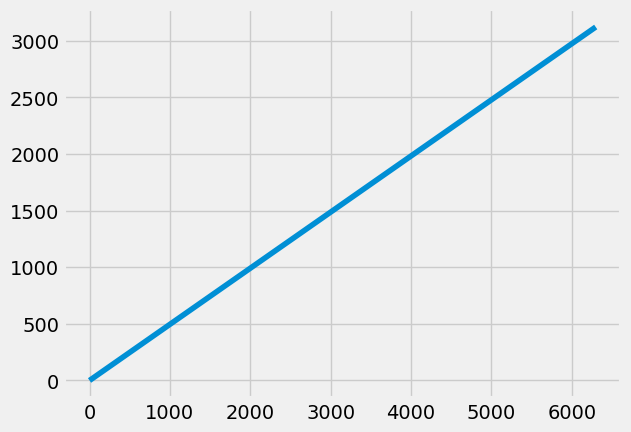

In [22]:
style.use('fivethirtyeight')
fig = plt.figure()
ax = fig.add_subplot(111)
ax.plot(np.array(real_time8))

# Defined Functions

In [9]:
def angle_between_twovec(v1,v2):
    cosine = np.dot(v1,v2)/(np.linalg.norm(v1)*np.linalg.norm(v2))
    if np.abs(cosine)>1:
        print(cosine)
        cosine=1
    theta = math.acos(cosine)*180/math.pi
    return theta

def bin_and_plot(X,Y,bins=10,label='',plot=False):
    #bins X and plots average of Y in each bin
    # Creating a DataFrame
    data = {
    'time': X,
    'activity': Y,
        }

    df = pd.DataFrame(data)

    df['vel_Bin'] = pd.cut(df['time'], bins=bins)

    # Calculate the mean of 'activity' in each bin
    mean_activity_by_bin = df.groupby('vel_Bin')['activity'].mean()
    mean_time_by_bin = df.groupby('vel_Bin')['time'].mean()

    # Extract bin edges and calculate bin width
    bin_edges = pd.cut(df['time'], bins=bins).unique()
    bin_width = bin_edges[0].right - bin_edges[0].left
    if plot:
        # Make the plot larger
        plt.figure(figsize=(12, 8))

        # Plotting the mean activity in each bin
        plt.bar(mean_time_by_bin, mean_activity_by_bin, width=bin_width, align='center')
        plt.title(label)
        plt.xlabel('time Bins')
        plt.ylabel('Mean Activity')
        plt.xticks(rotation=45, ha='right')
        plt.show()
    return df,mean_time_by_bin, mean_activity_by_bin,bin_width

def closest_index(A, b):
    #returns the index of vector A that has the closest value to b
    # Calculate the absolute differences between b and each element in A
    diff = np.abs(A - b)

    # Find the index of the element in A with the smallest difference
    idx = np.argmin(diff)

    # Return the index
    return idx



def every_second_component(vector,odd=0):
    new_vector = []
    if odd==0:
        for i in range(1, len(vector), 2):
            new_vector.append(vector[i])
    else:
        for i in range(0, len(vector), 2):
            new_vector.append(vector[i]) 
    return new_vector  

def compute_mean_everySec(matrix):
    #computes the com of the worm
    even_columns = matrix[:, ::2]  # All rows, even columns
    odd_columns = matrix[:, 1::2]  # All rows, odd columns
    # Compute mean of even columns
    mean_even_columns = np.mean(even_columns, axis=1)
    mean_odd_columns = np.mean(odd_columns, axis=1)
    return mean_even_columns, mean_odd_columns

def convertToFformat(ActVector,thresh=0.1):
    '''
    convert the intensity vector F to the format (F-F0)/F0
    '''
    if len(np.nonzero(ActVector)[0])>100:
        Sort = np.argsort(ActVector)
        print(np.shape(ActVector))
        ActVector_s = ActVector[Sort]
        ActVector_s = ActVector_s[(ActVector_s>0)]
        lowerBound = np.max(ActVector_s[:int(len(ActVector_s)*thresh)])#mean of the lowwest dropTresh percent of the activity
        seq = (np.nonzero(ActVector))[0]
        print(lowerBound)
        ActVector[seq] = (ActVector[seq]-lowerBound*np.ones(len(seq)))/lowerBound
        
    return ActVector

def compute_length(points):
    dx = np.diff(every_second_component(points,1))
    dy = np.diff(every_second_component(points,0))
    distances = np.sqrt(dx**2 + dy**2)
    
    # Compute total length of the curve
    total_length = np.sum(distances)
    
    print("Total length of the curve:", total_length)
    return total_length


def convert_properly(ActVector_withZeros, thresh=0.1):
    seqG = np.nonzero(ActVector_withZeros)[0]
    print(seqG)
    ActVector_withZeros[seqG]=convertToFformat(ActVector_withZeros[seqG],thresh)
    return ActVector_withZeros
    
def convert20to80(Xcoord,Ycoord):
    t = np.linspace(0, 19, len(Xcoord))

    # Create cubic spline interpolators for x and y as functions of t
    spline_x = interp1d(t, Xcoord, kind='cubic')
    spline_y = interp1d(t, Ycoord, kind='cubic')

    # Create new parameterization for the 20 equally spaced points
    new_t = np.linspace(0, 19, 80)

    # Calculate the 20 points' x and y coordinates
    new_x = spline_x(new_t)
    new_y = spline_y(new_t)
    return new_x, new_y

def convert20to80_equidistant(Xcoord,Ycoord):
    
    dx = np.diff(Xcoord)
    dy = np.diff(Ycoord)
    ds = np.sqrt(dx**2 + dy**2)
    
    # Compute cumulative arc length
    s = np.concatenate([[0], np.cumsum(ds)])
    
    # Interpolate the parameter to get equal distance segments
    num_points = 80  # Number of points with equal distance segments
    s_equal = np.linspace(0, s[-1], num_points)
    x_interp = interp1d(s, Xcoord, kind='linear')(s_equal)
    y_interp = interp1d(s, Ycoord, kind='linear')(s_equal)
    return x_interp,y_interp

def convert20toN_equidistant(Xcoord,Ycoord,N=80):
    
    dx = np.diff(Xcoord)
    dy = np.diff(Ycoord)
    ds = np.sqrt(dx**2 + dy**2)
    
    # Compute cumulative arc length
    s = np.concatenate([[0], np.cumsum(ds)])
    
    # Interpolate the parameter to get equal distance segments
    num_points = N  # Number of points with equal distance segments
    s_equal = np.linspace(0, s[-1], num_points)
    x_interp = interp1d(s, Xcoord, kind='linear')(s_equal)
    y_interp = interp1d(s, Ycoord, kind='linear')(s_equal)
    return x_interp,y_interp

def convert20toN_equidistant_smooth(Xcoord,Ycoord,N=80,sm=0,deg=2):
    
    dx = np.diff(Xcoord)
    dy = np.diff(Ycoord)
    ds = np.sqrt(dx**2 + dy**2)
    
    # Compute cumulative arc length
    s = np.concatenate([[0], np.cumsum(ds)])
    
    # Interpolate the parameter to get equal distance segments
    num_points = N  # Number of points with equal distance segments
    s_equal = np.linspace(0, s[-1], num_points)
    x_interp = interp1d(s, Xcoord, kind='linear')(s_equal)
    y_interp = interp1d(s, Ycoord, kind='linear')(s_equal)
    return x_interp,y_interp


def curvature(x, y):
    #x and y are vectors of x coord. and y coord. respectively
    dx_ds = np.gradient(x)
    dy_ds = np.gradient(y)
    d2x_ds2 = np.gradient(dx_ds)
    d2y_ds2 = np.gradient(dy_ds)
    
    numerator = (dx_ds * d2y_ds2 - dy_ds * d2x_ds2)
    denominator = (dx_ds**2 + dy_ds**2)**1.5
    
    curvature = numerator / denominator
    R = 1/curvature
    return curvature, R

def compute_perpendicular_vector(v):
    perpendicular_vector = np.array([-v[1], v[0]])

    return perpendicular_vector

def cross_product_2d(u, v):
    return u[0] * v[1] - u[1] * v[0]

def droptop5perc(velocityVec,thresh=0.05):
    #drops the highest 5 percent
    Sort = np.argsort(velocityVec)
    velocityVec_s = np.copy(velocityVec[Sort])
    velocityVec_s = velocityVec_s[velocityVec_s>0]
    upperBound = np.min(velocityVec_s[-int(len(velocityVec_s)*thresh):])#mean of the lowwest dropTresh percent of the activity
    above_thresh = (velocityVec > upperBound)
    velocityVec[above_thresh]=0
    velocityVec[above_thresh]=0
    return velocityVec
def dropbottom5perc(velocityVec,thresh=0.05):
    Sort = np.argsort(velocityVec)
    velocityVec_s = np.copy(velocityVec[Sort])
    velocityVec_s = velocityVec_s[(velocityVec_s>0) + (velocityVec_s<0)]
    lowerBound = np.max(velocityVec_s[:int(len(velocityVec_s)*thresh)])#mean of the lowwest dropTresh percent of the activity
    below_thresh = (velocityVec < lowerBound)
    #print("lowerBound"+str(lowerBound))
    velocityVec[below_thresh]=0
    velocityVec[below_thresh]=0
    return velocityVec

def extract_coordinates(Address,num=1):
    #returns the data in csv file
    file = open(Address[0])
    type(file)
    
    csvreader = csv.reader(file)
    np.shape(csvreader)
    rows = []

    for row in csvreader:
        rows.append(row)
        
    print(np.shape(rows))
    
    if num==3:
        rowsArr0=np.array(rows[1:])
        rowsArr=np.array(rowsArr0[:,:-2])
        #print(rowsArr)
    else:
        rowsArr=np.array(rows[1:])
        
    
    shapeMat = np.shape(rowsArr)
    
    rowsArr_float = np.zeros(shapeMat)
    for i in range(shapeMat[0]):
        for j in range(shapeMat[1]):
            #print(rowsArr[i,j])
            if rowsArr[i,j]=='NA':
                rowsArr_float[i,j]= 0
            elif rowsArr[i,j]=='NaN':
                rowsArr_float[i,j]= 0    
            else:
                rowsArr_float[i,j]=float(rowsArr[i,j])  
            
    return rows,rowsArr_float


        
def make_panda_bin(Xvec,Yvec,b=20):
    data = {
        'velocity': Xvec,
        'activity': Yvec, 
            }
    df = pd.DataFrame(data)
    # Bin 'Dimension2'
    df['vel_Bin'] = pd.cut(df['velocity'], bins=b)
    
    # Calculate the mean of 'activity' in each bin
    mean_activity_by_bin = df.groupby('vel_Bin')['activity'].mean()
    # Extract bin edges and calculate bin width
    #bin_edges = pd.cut(df['velocity'], bins=b).unique().mid
    #bin_width = bin_edges[1] - bin_edges[0]

    # Calculate x-tick positions at the center of each bin
    #xtick_positions = bin_edges + bin_width / 2
    return df,mean_activity_by_bin

def compute_vector_z_score(vector,exclude_zero=True):
    
    if not exclude_zero:
        mean = np.mean(vector)
        std=np.std(vector)
        vector_zscore= (vector-mean)/std
    else:
        vector_zscore = np.zeros(np.shape(vector))
        mean = np.mean(vector[np.nonzero(vector)[0]])
        std=np.std(vector[np.nonzero(vector)[0]])
        vector_zscore[np.nonzero(vector)[0]] = (vector[np.nonzero(vector)[0]]-mean)/std
    return vector_zscore 



def get_nonzero_start_end(turn_timepoints):
    start_indices = []
    end_indices = []
    if not turn_timepoints[0]==0:
        start_indices.append(0)
    for i in range(len(turn_timepoints) - 1):
        if turn_timepoints[i] == 0 and not(turn_timepoints[i+1] == 0):
            start_indices.append(i+1)
        if not(turn_timepoints[i] == 0) and (turn_timepoints[i+1] == 0): 
            end_indices.append(i)
    if not turn_timepoints[-1]==0:
        end_indices.append(len(turn_timepoints)-1) 
    assert len(end_indices)==len(start_indices)        
    return start_indices,end_indices 

def interpolate_nanValues(x,y):
    x_interp = np.interp(np.arange(len(x)), np.arange(len(x))[~np.isnan(x)], x[~np.isnan(x)])
    y_interp = np.interp(np.arange(len(y)), np.arange(len(y))[~np.isnan(y)], y[~np.isnan(y)])
    return x_interp, y_interp






def plot_allworms_box(neurons,MegaData, L,vel3first=13,Zscore= True):
    %matplotlib widget
    fig,ax = plt.subplots(len(neurons),5,figsize=(10,len(neurons)*3))
    label= ['RIA','RIA','RIM','RIM','RIB','RIB','Sensory','term1','term2']
    
    for n in neurons:
        for d in range(5):
            rowsArr_float = MegaData[d,:L[d],:]
            nonz1  = np.nonzero(rowsArr_float1[:,n])
            
            Vel5 = dropbottom5perc(droptop5perc(rowsArr_float[:,vel3first],thresh=0.001),thresh=0.001)
            
            if Zscore:
                df,mean_time, mean_activity,width = bin_and_plot(compute_vector_z_score(Vel5[nonz1[0]]),compute_vector_z_score(rowsArr_float[nonz1[0],n]))
                #df = make_panda_bin(compute_vector_z_score(Vel5[nonz1[0]]),compute_vector_z_score(rowsArr_float[nonz1[0],n]))
            else:
                df,mean_time, mean_activity,width = bin_and_plot((Vel5[nonz1[0]]),(rowsArr_float[nonz1[0],n]))
                
            ax[n,d].bar(mean_time, mean_activity, width=width, align='center',edgecolor='white')            
            
        ax[n,0].set_title(label[n])    
    plt.show() 

def smooth_vec(rowsArr_floatloc0,sig=1,inter=0):
    rowsArr_floatloc1 = copy.deepcopy(rowsArr_floatloc0)
    smoothed_arr=np.copy(rowsArr_floatloc0)
    starts,end = get_nonzero_start_end(rowsArr_floatloc1)
    for t in range(len(starts)):
        
        if end[t]-starts[t]>3:
            smoothed_arr[starts[t]:end[t]] = gaussian_filter1d((rowsArr_floatloc1[starts[t]:end[t]]), sigma=sig)
        smoothed_arr_f = [np.float(x) for x in smoothed_arr]    
    return smoothed_arr_f

# import coordinates

In [23]:
rows1,rowsArr_float1 = UNF.extract_coordinates(Address1,num=1)
rowsloc1,rowsArr_floatloc1 = UNF.extract_coordinates(Address1_loc,num=1)

rows2,rowsArr_float2 = UNF.extract_coordinates(Address2,num=1)
rowsloc2,rowsArr_floatloc2 = UNF.extract_coordinates(worm2Head2,num=1)


rows3,rowsArr_float3 = UNF.extract_coordinates(Address3,num=1)
rowsloc3,rowsArr_floatloc3 = UNF.extract_coordinates(Address3_loc,num=1)

rows4,rowsArr_float4 = UNF.extract_coordinates(Address4,num=1)
rowsloc4,rowsArr_floatloc4 = UNF.extract_coordinates(Address4_loc,num=1)

rows5,rowsArr_float5 = UNF.extract_coordinates(Address5,num=1)
rowsloc5,rowsArr_floatloc5 = UNF.extract_coordinates(Address5_loc,num=1)

rows6,rowsArr_float6 = UNF.extract_coordinates(Address6,num=1)
rowsloc6,rowsArr_floatloc6 = UNF.extract_coordinates(Address6_loc,num=1)

rows7,rowsArr_float7 = UNF.extract_coordinates(Address7,num=1)
rowsloc7,rowsArr_floatloc7 = UNF.extract_coordinates(Address7_loc,num=1)

rows8,rowsArr_float8 = UNF.extract_coordinates(Address8,num=1)
rowsloc8,rowsArr_floatloc8 = UNF.extract_coordinates(Address8_loc,num=1)

rows8,rowsArr_float9 = UNF.extract_coordinates(Address9,num=1)
rowsloc8,rowsArr_floatloc9 = UNF.extract_coordinates(Address9_loc,num=1)

(2757, 30)
(7793, 14)
(4298, 33)
(9138, 41)
(4290, 30)
(9286, 40)
(5740, 23)
(12193, 41)
(8076, 23)
(11458, 41)
(6401, 23)
(12749, 23)
(6627, 23)
(14400, 41)
(6301, 23)
(12627, 41)
(6307, 23)
(11900, 41)


In [24]:
L1,x = np.shape(rowsArr_float1)
L2,x = np.shape(rowsArr_float2)
L3,x = np.shape(rowsArr_float3)
L4,x = np.shape(rowsArr_float4)
L5,x = np.shape(rowsArr_float5)
L6,x = np.shape(rowsArr_float6)
L7,x = np.shape(rowsArr_float7)
L8,x = np.shape(rowsArr_float8)
L9,x = np.shape(rowsArr_float9)
print(L6)
print(L9)

6400
6306


In [25]:
L7 = 5355
L8 = 3200
L9 = 1850
print(L6)
print(L7)

6400
5355


In [26]:
L=[L1,L2,L3,L4,L5,L6,L7,L8,L9]
n_title = ['RIA','RIA','RIM','RIM','RIB','RIB','Sensory','nrD1','loop1']


# Create new MegaData file

In [28]:

hf = h5py.File('MegaData6.h5', 'w')
hf.create_group('data_sets_info')
hf.create_group('data')

names=['0328','0401','0511','0807-first','0807-second']
hf.create_dataset('data_sets_info/names',data=names)
hf.create_dataset('data_sets_info/lowercam_length',data=L)
hf.create_dataset('data_sets_info/neuron_names',data=n_title)

<HDF5 dataset "neuron_names": shape (9,), type "|O">

# If MegaData is already available

In [29]:
h5 = h5py.File('MegaData7_9worms.h5', 'r')
L= h5['data_sets_info/lowercam_length']

[L1,L2,L3,L4,L5,L6,L7,L8]=L
MegaData = np.copy(h5['data/dataraw'])

In [33]:
zeros_to_add = np.zeros((1, 8100, 60))

MegaData = np.concatenate((MegaData, zeros_to_add), axis=0)

In [34]:
#worm1
timeStep = 0.25
pixel_size1 = 37#size of pixels in tenth um-for the movie from 0406
#worm2
fps2=3
pixel_size2 = 37.03#1000/27 size of pixels in tenth um-for the movie from 0401
#worm3
fps3=3
pixel_size3 = 21.73#1000/46#size of pixels in tenth um-for the movie from 0401
fps4 = 4
pixel_size3 = 19.23
fps6 = 4
pixel_size6 = 22.22
fps7 = 4
pixel_size7 = 19.6
fps8 = 4
pixel_size8 = 18.5
fps9 = 4
pixel_size9 = 16.6

In [35]:
L9

1850

# Description of Data:

In general seems sensory neuron is more clear in second zstack than the first one
# video1:0328-recording2 
    1:0(RIA1/L)
    2:1(RIA2/R)
    5:2(RIM2/R)
    7:3
    6:4(RIB2/R)
    8:5
    9:6#could be corrected
    12:7?
    10:8?
    4:9
    4:10?
 9-term2
 4-term1 

 11,12,13 term mid
 
 3 and 6 seem to be pairs
but 3 has an irrelevant position
#14:loop1,11:nrV1,15:nrD1,9:loop2,12:nrV2,4:nrD2
direction1, through zstack:  sensory neuron with second RIA(2)
# video2:0401
    11:0(RIA2/R)
    13:1(RIA1/L)
    7:2
    5:3(RIM2/R)
    9:4(RIM1/L)
    8:5
    2:6
    1:7
 1-term1,
 4-term2,
 2-term mid
 
 neurite 4 like 10 
#6(2/R) and 10(1/L) seem to be a pair (I think this is RIB)-10 is very dim in deep red
#5(2/R) and 9(1/L) seem to be a pair.
#4:loop2,3:nrV2,1:nrD2,18:nrD1,16:nrV1,17:loop1
direction1,through zstack: worm 2 is like worm 1, the sensory neuron attached to the second RIA

# video3: 0511
right side is the indeces in the csv file
probably in this video RIM is not captured

    1:0(RIA1/L)
    2:1(RIA2/R)
    5:2 (RIB2/R)
    3:3(RIM?)probably not RIM
    8:4(RIM?Idont think)
    16:5 sensory
    9:6
    10:7
    11:8
    12:9    
    15:12
#RIB is neuron 5 and RIM maybe neuron 8   
#6 term1
#14 term2
#except 15 the rest are term mid. 12 is the largest mid neurite. 13,11,10,9 are the smaller segments of midneurite
#19:loop1,18:nrV1,17:nrD1,14:loop2,12(or7?):nrV2,6:nrD2
#I think It can be annotated again with less rotation to get RIM but currently it suffers from bad-location annotationn
direction1,through zstack: same as the 2 before, sensory neuron at the second RIA stack (2)
# video4:0807-1
    1:0(RIA2/R)
    2:1(RIA1/L)
    10:2(RIB2/R)
    3:3(RIM2/R)
    7:4(RIB1/L)
    5:5
    6:6
    4:7(RIM1/L)
    11:8 (term2)
    12:9
#10 and 7 are pairs(Deep red RIB)
#3 and 4 seems to be pairs too
#17: loop2,13:nrV2,16:nrD2,12:loop1,14:nrV1,11:nrD1
direction2, through zstack: sensory near RIA2
# video5:0807-2
    1:0(RIA2/R)
    2:1(RIA1/L)
    3:2(RIM2/R)
    7:3(RIM1/L)
    10:4(RIB2/R)
    5:5
    9:6(RIB1/L)
    8:7
    12:8
    11:9
#10 and 9 are pairs (Deep red RIB)    
#3 and 7 can be pair too
#14: loop2,15:nrV2,13:nrD2,12:loop1,4:nrV1,11:nrD1
direction2, through zstack: sensory near RIA2
neurites annotation could be improved
# video6: 2024-09-17W3
    1:0(RIA1/L)
    2:1(RIA2/R)
    4:2(RIM1/L)
    6:3(RIM2/R)
    3:4(RIB1/L)
    7:5(RIB2/R)
    10:6
    11:7
    12:8
    11:9
    13:39
    16:40
    11:27
    14:28
#3 and 7 are pairs (Deep red RIB)    
#6 and 4 can be pair too
The direction of the worm is more like the first three recordings
#12: loop1, 14:loop2,11:nrD1,11:nrD2,13:nrV1, 16:nrV2
direction1, through zstack: first sensory with 2 separated RIMRIB near RIA1 then the 2 close RIMRIB

# video7: 2024-09-20W1
    1:0(RIA1/L)
    2:1(RIA2/R)
    4:2(RIM1/L)
    7:3(RIM2/R)
    3:4(RIB1/L)
    6:5(RIB2/R)
    5:6
    11:7
    12:8
    11:9
    13:39
    16:40
    11:27
    14:28
#3 and 6 are pairs (Deep red RIB)    
#4 and 7 can be pair too
#sensory neuron seems to be neuron 5
The direction of the worm changes at around frames 5356-5361
#12: loop1, 14&19:loop2,11:nrD1,20:nrD2,13&17:nrV1, 16&18:nrV2
direction2, through zstack: first 2 close RIMRIB near RIA2 then sensory with 2 separated RIMRIB near RIA1 

# order of savd data in MegaData file:

0 RIA,1 RIA,2 RIM,3 RIM,4 RIB,5 RIB,6 sensory,7: nrD1 ,8: loop1, 9 neuron or neurite sum,

10 odor,11: uppercamera_index,12: lower_camera_time_stamp,13: v_center_long,

14v_center_signed_long,15v_center_medium,16v_center_signed_medium,17v_center_short,18v_center_signed_short,
19: v_head_long,20: v_tail,

21: v_headsigned_short, 22 v_headsigned_medium, 23 v_headsigned_long, 24 v_head_short,25 v_head_medium, 26:head curvature,
27: nrD2, 28: loop2,

29:head perpandicular_short, 30:head perpandicular_medium, 31:head perpandicular_long, 32:tail velocity perpendicular long, 33:tail velocity_medium, 34:tail velocity_short, 35: tail curvature, 36: merged neurites, 37:component of head vector perpandicular to the center vector. 38: component of a head vector parpendicular to the neck vector,39:nrV1,40:nrV2, 41,42,43:v_centermean_signed/7/15 computed differently. 44:bad frames in the upper camera. 45/46/47: mid body angular velocity theta short/medium/long.48:acceleration. (49,50):head Vector_x,y. (49,50):head Vector x,y. (51,52):neck vector x,y, (53,54):center vector x,y, (55,56):center point location x,y

## if you need to update activity of the first 5 worm

In [130]:
#the array containing all the neurons and all the velocity/speeds of the 5 worms
#8100 is largest than the maximum of all lower camera frames
# the activity saved here is raw and devided by red
#convert  0807 movies into deltaF/F0 format

MegaData[0,:L1,:2] = rowsArr_float1[:,:2]
MegaData[0,:L1,2] = rowsArr_float1[:,2]#RIM
MegaData[0,:L1,4] = rowsArr_float1[:,4]#RIB
MegaData[0,:L1,6] = rowsArr_float1[:,5]#sensory
MegaData[0,:L1,7] = convert_properly(GreenActivity_devided1[15,:])#nrD1
MegaData[0,:L1,8] = convert_properly(GreenActivity_devided1[14,:])#loop1
MegaData[0,:L1,10] = rowsArr_float1[:,13]
MegaData[0,:L1,11] = rowsArr_float1[:,14]
MegaData[0,:L1,12] = real_time1 
MegaData[0,:L1,13] = rowsArr_float1[:,29]*pixel_size1/100
MegaData[0,:L1,17] = rowsArr_float1[:,12]*pixel_size1/100#speed short
MegaData[0,:L1,18] = rowsArr_float1[:,11]*pixel_size1/100#velo short
MegaData[0,:L1,28] = convert_properly(GreenActivity_devided1[9,:])#loop2
MegaData[0,:L1,27] = convert_properly(GreenActivity_devided1[4,:])#nrD2
MegaData[0,:L1,39] = convert_properly(GreenActivity_devided1[11,:])#nrV1
MegaData[0,:L1,40] = convert_properly(GreenActivity_devided1[12,:])#nrV2

MegaData[1,:L2,0] = convert_properly(GreenActivity_devided2[13,:])#RIAL
MegaData[1,:L2,1] = convert_properly(GreenActivity_devided2[11,:])#RIAR
MegaData[1,:L2,2] = convert_properly(GreenActivity_devided2[9,:])#RIML
MegaData[1,:L2,3] = convert_properly(GreenActivity_devided2[5,:])#RIMR
MegaData[1,:L2,4] = convert_properly(GreenActivity_devided2[10,:])#RIBL
MegaData[1,:L2,5] = convert_properly(GreenActivity_devided2[6,:])#RIBR
MegaData[1,:L2,6] = rowsArr_float2[:,5]#sensory
MegaData[1,:L2,7] = convert_properly(GreenActivity_devided2[1,:])#nrD1
MegaData[1,:L2,8] = convert_properly(GreenActivity_devided2[4,:])#loop1
MegaData[1,:L2,10] = rowsArr_float2[:,13]
MegaData[1,:L2,11] = rowsArr_float2[:,14]
MegaData[1,:L2,12] = real_time2 
MegaData[1,:L2,13] = rowsArr_float2[:,29]*pixel_size2/100
MegaData[1,:L2,17] = rowsArr_float2[:,12]*pixel_size2/100
MegaData[1,:L2,18] = rowsArr_float2[:,11]*pixel_size2/100
MegaData[1,:L2,27] = convert_properly(GreenActivity2stack[17,:])#nrD2
MegaData[1,:L2,28] = convert_properly(GreenActivity2stack[18,:])#loop2
MegaData[1,:L2,39] = convert_properly(GreenActivity_devided2[3,:])#nrV1
MegaData[1,:L2,40] = convert_properly(GreenActivity2stack[16,:])#nrV2

MegaData[2,:L3,:2] = rowsArr_float3[:,:2]
#MegaData[2,:L3,2] = rowsArr_float3[:,3]#RIM
#MegaData[2,:L3,3] = rowsArr_float3[:,4]#RIM
MegaData[2,:L3,2] = convert_properly(GreenActivity_devided3[3,:])#RIM-probably there is no RIM for this worm
MegaData[2,:L3,3] = convert_properly(GreenActivity_devided3[8,:])#RIM 
MegaData[2,:L3,4] = convert_properly(GreenActivity_devided3[5,:])#RIB
MegaData[2,:L3,5] = convert_properly(GreenActivity_devided3[5,:])#RIB
#MegaData[2,:L3,5] = rowsArr_float3[:,2]#RIB---not sure
MegaData[2,:L3,6] = rowsArr_float3[:,5]#sensory
MegaData[2,:L3,7] = convert_properly(droptop5perc(dropbottom5perc(GreenActivity_devided3[17,:],0.005),0.005))#nrD1
MegaData[2,:L3,8] = convert_properly(droptop5perc(dropbottom5perc(GreenActivity_devided3[19,:],0.005),0.005))#loop1
MegaData[2,:L3,10] = rowsArr_float3[:,15]
MegaData[2,:L3,11] = rowsArr_float3[:,16]
MegaData[2,:L3,12] = real_time3 
MegaData[2,:L3,13] = rowsArr_float3[:,29]*pixel_size3/100
MegaData[2,:L3,17] = rowsArr_float3[:,14]*pixel_size3/100
MegaData[2,:L3,18] = rowsArr_float3[:,13]*pixel_size3/100
MegaData[2,:L3,27] = convert_properly(droptop5perc(dropbottom5perc(GreenActivity_devided3[6,:],0.005),0.005))#nrD2
MegaData[2,:L3,28] = convert_properly(droptop5perc(dropbottom5perc(GreenActivity3stack[14,:],0.005),0.005))#loop2
MegaData[2,:L3,39] = convert_properly(droptop5perc(dropbottom5perc(GreenActivity_devided3[18,:],0.005),0.005))#nrV1
MegaData[2,:L3,40] = convert_properly(droptop5perc(dropbottom5perc(GreenActivity3stack[12,:],0.005),0.005))#nrV2


MegaData[3,:L4,0] = convert_properly(rowsArr_float4[:,1])#RIAL
MegaData[3,:L4,1] = convert_properly(rowsArr_float4[:,0])#RIAR
MegaData[3,:L4,2] = convert_properly(rowsArr_float4[:,7])#RIML
MegaData[3,:L4,3] = convert_properly(rowsArr_float4[:,3])#RIMR
MegaData[3,:L4,4] = convert_properly(rowsArr_float4[:,4])#RIBL
MegaData[3,:L4,5] = convert_properly(rowsArr_float4[:,2])#RIBR
MegaData[3,:L4,6] = convert_properly(rowsArr_float4[:,5])#sensory
MegaData[3,:L4,7] = convert_properly(droptop5perc(dropbottom5perc(GreenActivity4stack[11,:],0.002),0.002))#nrD1
MegaData[3,:L4,8] = convert_properly(droptop5perc(dropbottom5perc(GreenActivity4stack[12,:],0.002),0.002))#loop1
MegaData[3,:L4,10] = rowsArr_float4[:,10]
MegaData[3,:L4,11] = rowsArr_float4[:,11]
MegaData[3,:L4,12] = real_time4 
MegaData[3,:L4,13] = rowsArr_float4[:,17]
MegaData[3,:L4,14] = rowsArr_float4[:,18]
MegaData[3,:L4,17] = rowsArr_float4[:,12]#speed short
MegaData[3,:L4,18] = rowsArr_float4[:,13]#velo
MegaData[3,:L4,28] = convert_properly(droptop5perc(dropbottom5perc(GreenActivity4stack[17,:],0.002),0.002))#loop2
MegaData[3,:L4,27] = convert_properly(droptop5perc(dropbottom5perc(GreenActivity4stack[16,:],0.002),0.002))#nrD2
MegaData[3,:L4,39] = convert_properly(droptop5perc(dropbottom5perc(GreenActivity4stack[14,:],0.002),0.002))#nrV1
MegaData[3,:L4,40] = convert_properly(droptop5perc(dropbottom5perc(GreenActivity4stack[13,:],0.002),0.002))#nrV2

MegaData[4,:L5,0] = convert_properly(rowsArr_float5[:,1])#RIAL
MegaData[4,:L5,1] = convert_properly(rowsArr_float5[:,0])#RIAR
MegaData[4,:L5,2] = convert_properly(rowsArr_float5[:,3])#RIML
MegaData[4,:L5,3] = convert_properly(rowsArr_float5[:,2])#RIMR
MegaData[4,:L5,4] = convert_properly(rowsArr_float5[:,6])#RIBL
MegaData[4,:L5,5] = convert_properly(rowsArr_float5[:,4])#RIBR
MegaData[4,:L5,6] = convert_properly(rowsArr_float5[:,5])#sensory
MegaData[4,:L5,7] = convert_properly(droptop5perc(dropbottom5perc(GreenActivity5stack[11,:],0.002),0.002))#nrD1
MegaData[4,:L5,8] = convert_properly(droptop5perc(dropbottom5perc(GreenActivity5stack[12,:],0.002),0.002))#loop1
MegaData[4,:L5,10] = rowsArr_float5[:,10]
MegaData[4,:L5,11] = rowsArr_float5[:,11]
MegaData[4,:L5,12] = real_time5 
MegaData[4,:L5,13] = rowsArr_float5[:,17]
MegaData[4,:L5,14] = rowsArr_float5[:,18]
MegaData[4,:L5,17] = rowsArr_float5[:,12]
MegaData[4,:L5,18] = rowsArr_float5[:,13]
MegaData[4,:L5,28] = convert_properly(droptop5perc(dropbottom5perc(GreenActivity5stack[14,:],0.002),0.002))#loop2
MegaData[4,:L5,27] = convert_properly(droptop5perc(dropbottom5perc(GreenActivity5stack[13,:],0.002),0.002))#nrD2
MegaData[4,:L5,39] = convert_properly(droptop5perc(dropbottom5perc(GreenActivity5stack[4,:],0.002),0.002))#nrV1
MegaData[4,:L5,40] = convert_properly(droptop5perc(dropbottom5perc(GreenActivity5stack[15,:],0.002),0.002))#nrV2

[  15   16   17 ... 2753 2754 2755]
(2227,)
0.015290483
[  15   16   17 ... 2753 2754 2755]
(2250,)
0.039176986
[   5   11   12 ... 2753 2754 2755]
(2515,)
0.04699521
[  14   15   16 ... 2753 2754 2755]
(1903,)
0.7669014
[   5   11   12 ... 2753 2754 2755]
(2455,)
0.78822905
[  15   16   17 ... 2753 2754 2755]
(2230,)
0.7413419
[   0    1    2 ... 4285 4286 4287]
(2367,)
1.0344653
[   0    1    2 ... 4284 4285 4286]
(2310,)
0.9844634
[   0    1    2 ... 4285 4286 4287]
(2360,)
0.83648866
[   0    1    2 ... 4285 4286 4287]
(2290,)
0.87221605
[   0    1    2 ... 4285 4286 4287]
(2285,)
0.8688986
[   0    1    2 ... 4268 4269 4270]
(1981,)
0.88612604
[   0    1    2 ... 4285 4286 4287]
(2216,)
0.8714309
[   0    1    2 ... 4280 4283 4285]
(2253,)
0.87859416
[  25   27   28 ... 4284 4285 4286]
(2516,)
0.98259205
[  25   27   28 ... 4284 4285 4286]
(2430,)
1.036694
[  25   27   28 ... 4284 4285 4286]
(2547,)
0.945214
[  25   27   28 ... 4284 4285 4286]
(2518,)
1.0312645
[  25   27   29 ...

In [31]:
#modify neurites signal
MegaData[1,:L2,7] = convert_properly(GreenActivity2stack[1,:])#nrD1
MegaData[1,:L2,27] = convert_properly(GreenActivity2stack[17,:])#nrD2
MegaData[1,:L2,28] = convert_properly(GreenActivity2stack[18,:])#loop2
MegaData[1,:L2,40] = convert_properly(GreenActivity2stack[16,:])#nrV2

MegaData[2,:L3,28] = convert_properly(droptop5perc(dropbottom5perc(GreenActivity3stack[14,:],0.005),0.005))#loop2
MegaData[2,:L3,40] = convert_properly(droptop5perc(dropbottom5perc(GreenActivity3stack[12,:],0.005),0.005))#nrV2

MegaData[3,:L4,28] = convert_properly(droptop5perc(dropbottom5perc(GreenActivity4stack[17,:],0.002),0.002))#loop2
MegaData[3,:L4,27] = convert_properly(droptop5perc(dropbottom5perc(GreenActivity4stack[16,:],0.002),0.002))#nrD2
MegaData[3,:L4,39] = convert_properly(droptop5perc(dropbottom5perc(GreenActivity4stack[14,:],0.002),0.002))#nrV1
MegaData[3,:L4,40] = convert_properly(droptop5perc(dropbottom5perc(GreenActivity4stack[13,:],0.002),0.002))#nrV2
MegaData[3,:L4,7] = convert_properly(droptop5perc(dropbottom5perc(GreenActivity4stack[11,:],0.002),0.002))#nrD1
MegaData[3,:L4,8] = convert_properly(droptop5perc(dropbottom5perc(GreenActivity4stack[12,:],0.002),0.002))#loop1

MegaData[4,:L5,28] = convert_properly(droptop5perc(dropbottom5perc(GreenActivity5stack[14,:],0.02),0.02))#loop2
MegaData[4,:L5,27] = convert_properly(droptop5perc(dropbottom5perc(GreenActivity5stack[13,:],0.02),0.02))#nrD2
MegaData[4,:L5,39] = convert_properly(droptop5perc(dropbottom5perc(GreenActivity5stack[4,:],0.02),0.02))#nrV1
MegaData[4,:L5,40] = convert_properly(droptop5perc(dropbottom5perc(GreenActivity5stack[15,:],0.02),0.02))#nrV2
MegaData[4,:L5,7] = convert_properly(droptop5perc(dropbottom5perc(GreenActivity5stack[11,:],0.02),0.02))#nrD1
MegaData[4,:L5,8] = convert_properly(droptop5perc(dropbottom5perc(GreenActivity5stack[12,:],0.02),0.02))#loop1
MegaData[4,:L5,3] = convert_properly(droptop5perc(dropbottom5perc(GreenActivity5stack[7,:],0.02),0.002))#RIM

[   0    1    2 ... 4285 4286 4287]
(2358,)
0.012349872
[   0    1    2 ... 4268 4269 4270]
(1988,)
107.66102
[   0    1    2 ... 4285 4286 4287]
(2288,)
106.65151
[   0    1    2 ... 4280 4283 4285]
(2257,)
107.22642
[  27   29   30 ... 4284 4285 4286]
(1618,)
107.00961
[  27   28   31 ... 4284 4285 4286]
(2069,)
108.818184
[  27   28   29 ... 5736 5737 5738]
(4429,)
108.14414
[  27   28   29 ... 5735 5736 5737]
(4194,)
107.268295
[  27   28   29 ... 5736 5737 5738]
(4531,)
108.056335
[  27   28   30 ... 5736 5737 5738]
(4507,)
106.97183
[  25   27   28 ... 5735 5736 5737]
(4492,)
108.34646
[  14   25   27 ... 5736 5737 5738]
(4521,)
111.95082


# Correct worm 2,4,5's direction issues

In [ ]:
MegaData[1,:L2,0] = convert_properly(GreenActivity_devided2[13,:])#RIAL
MegaData[1,:L2,1] = convert_properly(GreenActivity_devided2[11,:])#RIAR
MegaData[1,:L2,2] = convert_properly(GreenActivity_devided2[9,:])#RIML
MegaData[1,:L2,3] = convert_properly(GreenActivity_devided2[5,:])#RIMR
MegaData[1,:L2,4] = convert_properly(GreenActivity_devided2[10,:])#RIBL
MegaData[1,:L2,5] = convert_properly(GreenActivity_devided2[6,:])#RIBR
##Switch orders of L/R
MegaData[3,:L4,0] = convert_properly(rowsArr_float4[:,1])#RIAL
MegaData[3,:L4,1] = convert_properly(rowsArr_float4[:,0])#RIAR
MegaData[3,:L4,2] = convert_properly(rowsArr_float4[:,7])#RIML
MegaData[3,:L4,3] = convert_properly(rowsArr_float4[:,3])#RIMR
MegaData[3,:L4,4] = convert_properly(rowsArr_float4[:,4])#RIBL
MegaData[3,:L4,5] = convert_properly(rowsArr_float4[:,2])#RIBR
##Switch orders of L/R
MegaData[4,:L5,0] = convert_properly(rowsArr_float5[:,1])#RIAL
MegaData[4,:L5,1] = convert_properly(rowsArr_float5[:,0])#RIAR
MegaData[4,:L5,2] = convert_properly(rowsArr_float5[:,3])#RIML
MegaData[4,:L5,3] = convert_properly(rowsArr_float5[:,2])#RIMR
MegaData[4,:L5,4] = convert_properly(rowsArr_float5[:,6])#RIBL
MegaData[4,:L5,5] = convert_properly(rowsArr_float5[:,4])#RIBR

# Add the 6th dataset

In [16]:
zeros_slice = np.zeros((2, 8100, 60))
MegaData = np.append(MegaData, zeros_slice, axis=0)
L = [L1,L2,L3,L4,L5,L6]
print(np.shape(MegaData))
MegaData[5,:L6,0] = UNF.convert_properly(rowsArr_float6[:,0])
MegaData[5,:L6,1] = UNF.convert_properly(rowsArr_float6[:,1])
MegaData[5,:L6,2] = UNF.convert_properly(UNF.droptop5perc(UNF.dropbottom5perc(GreenActivity_devided6[4,:],0.005),0.005))#convert_properly(rowsArr_float6[:,2])#RIM
MegaData[5,:L6,3] = UNF.convert_properly(UNF.droptop5perc(UNF.dropbottom5perc(GreenActivity_devided6[6,:],0.005),0.005))#convert_properly(rowsArr_float6[:,3])#RIM
MegaData[5,:L6,4] = UNF.convert_properly(UNF.droptop5perc(UNF.dropbottom5perc(GreenActivity_devided6[3,:],0.005),0.005))#convert_properly(rowsArr_float6[:,4])#RIB
MegaData[5,:L6,5] = UNF.convert_properly(UNF.droptop5perc(UNF.dropbottom5perc(GreenActivity_devided6[7,:],0.005),0.005))#convert_properly(rowsArr_float6[:,6])#RIB
MegaData[5,:L6,6] = UNF.convert_properly(rowsArr_float6[:,5])#sensory
MegaData[5,:L6,7] = UNF.convert_properly(UNF.droptop5perc(UNF.dropbottom5perc(GreenActivity6stack[11,:],0.01),0.01))#nrD1
MegaData[5,:L6,8] = UNF.convert_properly(UNF.droptop5perc(UNF.dropbottom5perc(GreenActivity6stack[12,:],0.01),0.01))#loop1
MegaData[5,:L6,10] = rowsArr_float6[:,10]
MegaData[5,:L6,11] = rowsArr_float6[:,11]
MegaData[5,:L6,12] = real_time6 
MegaData[5,:L6,13] = rowsArr_float6[:,17]
MegaData[5,:L6,14] = rowsArr_float6[:,18]
MegaData[5,:L6,17] = rowsArr_float6[:,12]
MegaData[5,:L6,18] = rowsArr_float6[:,13]
MegaData[5,:L6,28] = UNF.convert_properly(UNF.droptop5perc(UNF.dropbottom5perc(GreenActivity6stack[14,:],0.01),0.01))#loop2
MegaData[5,:L6,27] = UNF.convert_properly(UNF.droptop5perc(UNF.dropbottom5perc(GreenActivity6stack[11,:],0.01),0.01))#nrD2
MegaData[5,:L6,39] = UNF.convert_properly(UNF.droptop5perc(UNF.dropbottom5perc(GreenActivity6stack[13,:],0.01),0.01))#nrV1
MegaData[5,:L6,40] = UNF.convert_properly(UNF.droptop5perc(UNF.dropbottom5perc(GreenActivity6stack[16,:],0.01),0.01))#nrV2

(7, 8100, 60)
[ 109  110  111 ... 6397 6398 6399]
(4665,)
0.3564169704914093
[ 207  208  209 ... 6397 6398 6399]
(4662,)
0.24748541414737701
[ 103  104  105 ... 6397 6398 6399]
(4354,)
0.9568731188774109
[ 103  104  105 ... 6397 6398 6399]
(4583,)
0.9645490646362305
[ 103  104  105 ... 6397 6398 6399]
(4479,)
0.9423648715019226
[ 103  104  105 ... 6397 6398 6399]
(4597,)
0.933086633682251
[ 103  105  106 ... 6397 6398 6399]
(4333,)
0.9916588068008423
[ 103  104  105 ... 6397 6398 6399]
(4794,)
105.86487
[ 103  104  105 ... 6397 6398 6399]
(4727,)
106.792114
[ 103  105  106 ... 6397 6398 6399]
(4795,)
106.36066
[ 103  104  105 ... 6397 6398 6399]
(4704,)
0.0064273216
[ 103  105  106 ... 6397 6398 6399]
(4540,)
104.8806
[ 103  105  106 ... 6397 6398 6399]
(4786,)
106.379745


In [61]:
MegaData[2,:L3,4] = (UNF.convert_properly(GreenActivity_devided3[5,:]))#RIB
MegaData[2,:L3,5] = (UNF.convert_properly(GreenActivity_devided3[5,:]))#RIB
MegaData[2,:L3,2] = (UNF.convert_properly(GreenActivity_devided3[3,:]))#RIM-probably there is no RIM for this worm
MegaData[2,:L3,3] = (UNF.convert_properly(GreenActivity_devided3[8,:]))#RIM

MegaData[5,:L6,2] = (UNF.convert_properly(UNF.droptop5perc(UNF.dropbottom5perc(GreenActivity_devided6[4,:],0.005),0.005)))#convert_properly(rowsArr_float6[:,2])#RIM
MegaData[5,:L6,3] = (UNF.convert_properly(UNF.droptop5perc(UNF.dropbottom5perc(GreenActivity_devided6[6,:],0.005),0.005)))#convert_properly(rowsArr_float6[:,3])#RIM
MegaData[5,:L6,4] = (UNF.convert_properly(UNF.droptop5perc(UNF.dropbottom5perc(GreenActivity_devided6[3,:],0.005),0.005)))#convert_properly(rowsArr_float6[:,4])#RIB
MegaData[5,:L6,5] = (UNF.convert_properly(UNF.droptop5perc(UNF.dropbottom5perc(GreenActivity_devided6[7,:],0.005),0.005)))

[  25   27   28 ... 4284 4285 4286]
(2514,)
1.0490283
[  25   27   28 ... 4284 4285 4286]
(2513,)
1.2826154
[  25   27   28 ... 4284 4285 4286]
(2514,)
1.0291535
[  25   27   28 ... 4284 4285 4286]
(2428,)
0.70992965
[ 103  104  105 ... 6397 6398 6399]
(4549,)
0.6828035
[ 103  104  105 ... 6397 6398 6399]
(4788,)
0.47411108
[ 103  104  105 ... 6397 6398 6399]
(4679,)
1.4290721
[ 103  104  105 ... 6397 6398 6399]
(4801,)
3.374863


# Add the 7th dataset

In [18]:
L7

5355

In [69]:
#zeros_slice = np.zeros((2, 8100, 60))
#MegaData = np.append(MegaData[:6,:,:], zeros_slice, axis=0)
L = [L1,L2,L3,L4,L5,L6,L7]
print(np.shape(MegaData))

a=1
MegaData[6,:L7,0] = UNF.convert_properly(UNF.droptop5perc(UNF.dropbottom5perc(GreenActivity7[1,:L7],0.01),0.01))
MegaData[6,:L7,1] = UNF.convert_properly(UNF.droptop5perc(UNF.dropbottom5perc(GreenActivity7[2,:L7],0.01),0.01))
MegaData[6,:L7,2] = UNF.convert_properly(UNF.droptop5perc(UNF.dropbottom5perc(GreenActivity7[4,:L7],0.005),0.01))
MegaData[6,:L7,3] = UNF.convert_properly(UNF.droptop5perc(UNF.dropbottom5perc(GreenActivity7[7,:L7],0.005),0.01))
MegaData[6,:L7,4] = UNF.convert_properly(UNF.dropbottom5perc(GreenActivity_devided7[3,:L7],0.01))
MegaData[6,:L7,5] = UNF.convert_properly(UNF.dropbottom5perc(GreenActivity_devided7[6,:L7],0.01))
MegaData[6,:L7,6] = UNF.convert_properly(UNF.droptop5perc(UNF.dropbottom5perc(GreenActivity7[5,:L7],0.01),0.01))
MegaData[6,:L7,7] = UNF.convert_properly(UNF.droptop5perc(UNF.dropbottom5perc(GreenActivity7[11,:L7],0.02),0.02))
MegaData[6,:L7,8] = UNF.convert_properly(UNF.droptop5perc(UNF.dropbottom5perc(GreenActivity7[12,:L7],0.02),0.02))
MegaData[6,:L7,10] = rowsArr_float7[:L7,10]
MegaData[6,:L7,11] = rowsArr_float7[:L7,11]
MegaData[6,:L7,12] = real_time7[0,:L7] 
MegaData[6,:L7,28] = UNF.convert_properly(UNF.droptop5perc(UNF.dropbottom5perc(GreenActivity7[14,:L7],0.02),0.02))#loop2
MegaData[6,:L7,27] = UNF.convert_properly(UNF.droptop5perc(UNF.dropbottom5perc(GreenActivity7[20,:L7],0.02),0.02))#nrD2
MegaData[6,:L7,39] = UNF.convert_properly(UNF.droptop5perc(UNF.dropbottom5perc(GreenActivity7[13,:L7],0.02),0.02))
MegaData[6,:L7,40] = UNF.convert_properly(UNF.droptop5perc(UNF.dropbottom5perc(GreenActivity7[18,:L7],0.02),0.02))

(8, 8100, 60)
[   0    1    2 ... 6623 6624 6625]
(5259,)
122.760414
[   0    1    2 ... 6623 6624 6625]
(5163,)
114.598946
[   5    6    7 ... 6623 6624 6625]
(5232,)
112.68965
[   5    6    7 ... 6623 6624 6625]
(4985,)
114.40741
[   5    6    7 ... 6623 6624 6625]
(5420,)
0.8539392
[   5    6    7 ... 6623 6624 6625]
(5060,)
0.9640049
[   4   34   35 ... 6623 6624 6625]
(5321,)
110.9829
[   0    1    2 ... 6623 6624 6625]
(4674,)
109.20588
[   4    5    6 ... 6623 6624 6625]
(4905,)
110.41346
[   4    5    6 ... 6623 6624 6625]
(4938,)
106.136986
[   0    1    2 ... 6623 6624 6625]
(4877,)
107.29293
[   0    1    2 ... 6623 6624 6625]
(4911,)
107.17333
[   0    1    2 ... 6623 6624 6625]
(4933,)
105.681816


# Add the 8th dataset. RIM strain

In [24]:
MegaData[7,:L8,0] = UNF.convert_properly(UNF.droptop5perc(UNF.dropbottom5perc(GreenActivity8[:L8],0.01),0.01))
MegaData[7,:L8,1] = UNF.convert_properly(UNF.droptop5perc(UNF.dropbottom5perc(GreenActivity_devided8[:L8],0.01),0.01))
MegaData[7,:L8,2] = UNF.convert_properly(UNF.droptop5perc(UNF.dropbottom5perc(GreenActivity8stack[:L8],0.01),0.01))

MegaData[7,:L8,10] = rowsArr_float8[:L8,10]
MegaData[7,:L8,11] = rowsArr_float8[:L8,11]
MegaData[7,:L8,12] = real_time8[:L8] 

[  20   21  128 ... 3197 3198 3199]
(2764,)
122.2728
[  20   21  110 ... 3197 3198 3199]
(2764,)
0.89004123
[  20   21  110 ... 3197 3198 3199]
(2764,)
0.8020249


In [ ]:
# updataed activity from separate channels:
GreenActivity30_gr8 = np.array(h_activity8gr["Mean_30perc/Green"])
GreenActivity_gr8 = np.array(h_activity8gr["Mean/Green"])
GreenActivity8ratio30 = np.array(h_activity8gr["Mean_30perc/ratio"])
GreenActivity8ratio = np.array(h_activity8gr["Mean/ratio"])

In [13]:
# updataed activity from separate channels:
MegaData[7,:L8,3] = UNF.convert_properly(GreenActivity30_gr8[:L8])
MegaData[7,:L8,4] = UNF.convert_properly(GreenActivity_gr8[:L8])
MegaData[7,:L8,5] = UNF.convert_properly(GreenActivity8ratio30[:L8])
MegaData[7,:L8,6] = UNF.convert_properly(GreenActivity8ratio[:L8])

[  20   21  128 ... 3197 3198 3199]
(2785,)
36.838833
[  20   21  128 ... 3197 3198 3199]
(2750,)
34.480778
[  20   21  128 ... 3197 3198 3199]
(2785,)
1.0601166
[  20   21  130 ... 3197 3198 3199]
(2260,)
1.2590377


# Add 9th worm, AVA strain

In [38]:
MegaData[8,:L9,0] = UNF.convert_properly(UNF.droptop5perc(UNF.dropbottom5perc(GreenActivity9[:L9],0.01),0.01))
MegaData[8,:L9,1] = UNF.convert_properly(UNF.droptop5perc(UNF.dropbottom5perc(GreenActivity_devided9[:L9],0.01),0.01))
MegaData[8,:L9,2] = UNF.convert_properly(UNF.droptop5perc(UNF.dropbottom5perc(GreenActivity9stack[:L9],0.01),0.01))
MegaData[8,:L9,2] = UNF.convert_properly(UNF.droptop5perc(UNF.dropbottom5perc(GreenActivity30_gr9[:L9],0.01),0.01))


MegaData[8,:L9,10] = rowsArr_float9[:L9,10]
MegaData[8,:L9,11] = rowsArr_float9[:L9,11]
MegaData[8,:L9,12] = real_time9[:L9] 

[   0    3    4 ... 1847 1848 1849]
(1420,)
6.30552
[   0    3    4 ... 1847 1848 1849]
(1420,)
0.030846452
[   0    3    4 ... 1847 1848 1849]
(1420,)
0.031482633
[   0    3    4 ... 1847 1848 1849]
(1420,)
7.7183404


In [37]:
GreenActivity_devided9 = np.array(h_activity9["Mean/ratio"])
GreenActivity9 = np.array(h_activity9["Mean/Green"])
real_time9 = np.array(h_activity9["Real_time_series"])
GreenActivity9stack = np.array(h_activity9["Mean_30perc/ratio"])
GreenActivity30_gr9 = np.array(h_activity9["Mean_30perc/Green"])

# Unify velocity

In [25]:
# Specify the path corrected point coordinates
csv_file_path1 = [Directory + 'body_part_time_course_corrected_03281.csv']
csv_file_path2 = [Directory + 'body_part_time_course_corrected_0401.csv']
csv_file_path3 = [Directory + 'body_part_time_course_corrected_0511.csv']

In [22]:
#save the indices of bad frames

BadupperCamera_frames4 = np.concatenate((np.arange(222,428),np.arange(500,692),np.arange(1154,1244),np.arange(2255,2285),
    np.arange(2600,2617),np.arange(3233,3250),np.arange(4074,4200),np.arange(2000,2070),
    np.arange(4100, 4200),np.arange(7800,8300),np.arange(8570,8650),np.arange(8900,8920),
    np.arange(9330,9360),np.arange(9885,9990),np.arange(10085,10105),np.arange(10294,10300),np.arange(10160,10173),
    np.arange(11480,11506),np.arange(11650,11690),np.arange(11874,11928),np.arange(12157,12166)))
BadupperCamera_frames4 = np.unique(BadupperCamera_frames4)
BadupperCamera_frames3 = np.arange(8000,8200)
for d in [3,4]:
    for t in range(L[d-1]):
        if d==3:
            if MegaData[d-1,t,11] in BadupperCamera_frames3:
                MegaData[d-1,t,44] = 1
        if d==4:
            if MegaData[d-1,t,11] in BadupperCamera_frames4:
                MegaData[d-1,t,44] = 1        


In [26]:
df1 = pd.read_csv(csv_file_path1[0], header=None)
df2 = pd.read_csv(csv_file_path2[0], header=None)
df3 = pd.read_csv(csv_file_path3[0], header=None)

In [40]:
fps1 = 4
fps2 = 3
fps3 = 3
fps4 = 4
fps5 = 4
fps6 = 4
fps7 = 4
fps8 = 4
fps9 = 4

In [39]:

#rowsloc2,rowsArr_floatloc2 = extract_coordinates(csv_file_path2 ,num=1)
rowsloc2,rowsArr_floatloc2 = UNF.extract_coordinates(worm2Head2 ,num=1)
rowsloc3,rowsArr_floatloc3 = UNF.extract_coordinates(worm3Head2 ,num=1)
rowsloc4,rowsArr_floatloc4 = UNF.extract_coordinates(worm4Head2 ,num=1)
rowsloc5,rowsArr_floatloc5 = UNF.extract_coordinates(worm5Head2 ,num=1)
rowsloc6,rowsArr_floatloc6 = UNF.extract_coordinates(worm6Head2 ,num=1)
rowsloc7,rowsArr_floatloc7 = UNF.extract_coordinates(worm7Head2 ,num=1)
rowsloc8,rowsArr_floatloc8 = UNF.extract_coordinates(worm8Head2 ,num=1)
rowsloc9,rowsArr_floatloc9 = UNF.extract_coordinates(worm9Head2 ,num=1)

(9138, 41)
(9287, 41)
(12193, 41)
(11459, 41)
(12749, 41)
(14400, 41)
(12627, 41)
(11900, 41)


## check the following cell indices

13v_center_long,

14v_center_signed_long,15v_center_medium,16v_center_signed_medium,17v_center_short,18v_center_signed_short,
19v_head_long,20v_tail,

21: v_headsigned_short, 22 v_headsigned_medium, 23 v_headsigned_long, 24 v_head_short,25 v_head_medium, 26:head curvature,
27: nrD2, 28: loop2,

29:head perpandicular_short, 30:head perpandicular_medium, 31:head perpandicular_long, 32:tail velocity perpendicular long, 33:tail velocity_medium, 34:tail velocity_short, 35: tail curvature, 36: merged neurites, 37:component of head vector perpandicular to the center vector. 38: component of a head vector parpendicular to the neck vector,39:nrV1,40:nrV2, 41,42,43:v_centermean_signed/7/15 computed differently. 44:bad frames in the upper camera. 45/46/47: mid body angular velocity theta short/medium/long. 48:acceleration. (49,50):head Vector x,y. (51,52):neck vector x,y, (53,54):center vector x,y, (55,56):center point location x,y

## averaging and smoothing coordinates of points

In [ ]:
# in case of averaging:
d=8
rowsArr_floatloct = copy.deepcopy(rowsArr_floatloc7)
for b in range(len(rowsArr_floatloct[0,:])):
    rowsArr_floatloct[:,b]= UNF.smooth_vec(rowsArr_floatloct[:,b])
rowsArr_floatloct[rowsArr_floatloct==0] = np.nan 
rowsArr_floatloct_mean = copy.deepcopy(rowsArr_floatloct[:,1:])

print(np.shape(rowsArr_floatloct_mean))

for i in range(L[d-1]-1):
    st = int(MegaData[d-1,i,11])
    end = int(MegaData[d-1,i+1,11])
    rowsArr_floatloct_mean[st:end,:] = np.nanmean(rowsArr_floatloct[st:end,1:],axis=0)

## Not averaging but smoothing the points

In [41]:
#or dont average the matrix
d=9
if d==1:
    rowsArr_floatloct = copy.deepcopy(rowsArr_floatloc1)
if d==2:
    rowsArr_floatloct = copy.deepcopy(rowsArr_floatloc2)    
if d==3:
    rowsArr_floatloct = copy.deepcopy(rowsArr_floatloc3)
if d==4:
    rowsArr_floatloct = copy.deepcopy(rowsArr_floatloc4)
if d==5:
    rowsArr_floatloct = copy.deepcopy(rowsArr_floatloc5)
if d==6:
    rowsArr_floatloct = copy.deepcopy(rowsArr_floatloc6)    
if d==7:
    rowsArr_floatloct = copy.deepcopy(rowsArr_floatloc7)  
if d==8:
    rowsArr_floatloct = copy.deepcopy(rowsArr_floatloc8)  
if d==9:
    rowsArr_floatloct = copy.deepcopy(rowsArr_floatloc9)  
    
for b in range(len(rowsArr_floatloct[0,:])):
    rowsArr_floatloct[:,b]= UNF.smooth_vec(rowsArr_floatloct[:,b])
rowsArr_floatloct[rowsArr_floatloct==0] = np.nan 
rowsArr_floatloct_mean = copy.deepcopy(rowsArr_floatloct[:,1:])

## Interpolate 7 (or 11) points to 80 points

In [42]:
extended80matrix = np.zeros((len(rowsArr_floatloct[:,3]),160))
extended20matrix = np.zeros((len(rowsArr_floatloct[:,3]),40))

for t in range(len(rowsArr_floatloct[:,0])):
    extended80matrix[t,0::2], extended80matrix[t,1::2] = UNF.convert20toN_equidistant_smooth(UNF.every_second_component(rowsArr_floatloct_mean[t,:],1),
                                                                                        UNF.every_second_component(rowsArr_floatloct_mean[t,:],0))
    extended20matrix[t,0::2], extended20matrix[t,1::2] = UNF.convert20toN_equidistant_smooth(UNF.every_second_component(rowsArr_floatloct_mean[t,:],1),
                                                                                        UNF.every_second_component(rowsArr_floatloct_mean[t,:],0),20)

In [43]:
p1,p2 = 2475,2485
L = [L1,L2,L3,L4,L5,L6,L7,L8,L9]
x1 = UNF.closest_index(MegaData[d-1,:L[d-1],11],p1)
x2 = UNF.closest_index(MegaData[d-1,:L[d-1],11],p2)


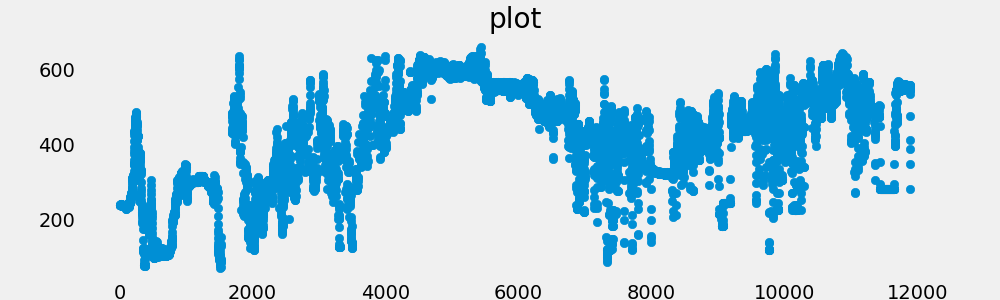

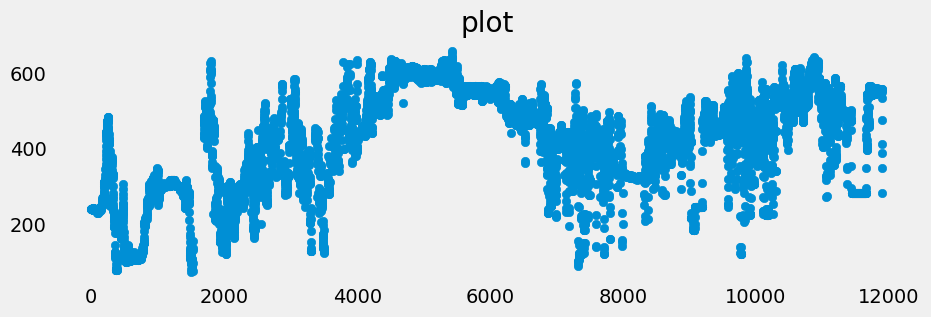

In [44]:
importlib.reload(UNF)
%matplotlib widget
UNF.plot1d(np.arange(len(extended80matrix[:,3])),extended80matrix[:,3],title='plot')

# Compute Head Curvature

In [45]:
#change the numbers in line 3 and 4 at each run
# The input to the first line is either the rowsArr_floatloc2/3/4/5 matrix or extended20matrix derived after
#averaging and equally distancing
df_ext_coord = copy.deepcopy(extended80matrix[:,:])#if it is 4 and 5 keep [1:,1:]
d=9
curve_head_signed = np.zeros((len(df_ext_coord[:,0]),1))
radius_head_signed = np.zeros((len(df_ext_coord[:,0]),1))
curve_tail_signed = np.zeros((len(df_ext_coord[:,0]),1))
radius_tail_signed = np.zeros((len(df_ext_coord[:,0]),1))
countnan=0
for t in range(len(df_ext_coord[:,0])):
    if not np.isnan(df_ext_coord[t,0]):
        C,R = UNF.curvature(df_ext_coord[t,0:10:2], df_ext_coord[t,1:10:2])
        C_t,R_t = UNF.curvature(df_ext_coord[t,150:160:2], df_ext_coord[t,151:160:2])
        print(C)
        curve_head_signed[t,0] = np.nanmean(C)
        radius_head_signed[t,0] = np.nanmean(R)
        
        curve_tail_signed[t,0] = np.nanmean(C_t)
        radius_tail_signed[t,0] = np.nanmean(R_t)
    else:
        print(str(t)+" is nan")
        countnan = countnan + 1

print(countnan)
indices = [int(i) for i in MegaData[d-1,:L[d-1],11]]

MegaData[d-1,:L[d-1],26] = curve_head_signed[indices,0]
MegaData[d-1,:L[d-1],35] = curve_tail_signed[indices,0]


[5.07839344e-16 7.82938887e-04 2.11523044e-03 1.88098141e-03
 1.09768487e-03]
[5.07839344e-16 7.82938887e-04 2.11523044e-03 1.88098141e-03
 1.09768487e-03]
[5.07839344e-16 7.82938887e-04 2.11523044e-03 1.88098141e-03
 1.09768487e-03]
[5.07839344e-16 7.82938887e-04 2.11523044e-03 1.88098141e-03
 1.09768487e-03]
[5.07839344e-16 7.82938887e-04 2.11523044e-03 1.88098141e-03
 1.09768487e-03]
[5.07839344e-16 7.82938887e-04 2.11523044e-03 1.88098141e-03
 1.09768487e-03]
[5.07839344e-16 7.82938887e-04 2.11523044e-03 1.88098141e-03
 1.09768487e-03]
[5.07839344e-16 7.82938887e-04 2.11523044e-03 1.88098141e-03
 1.09768487e-03]
[5.07839344e-16 7.82938887e-04 2.11523044e-03 1.88098141e-03
 1.09768487e-03]
[5.07839344e-16 7.82938887e-04 2.11523044e-03 1.88098141e-03
 1.09768487e-03]
[5.07839344e-16 7.82938887e-04 2.11523044e-03 1.88098141e-03
 1.09768487e-03]
[5.07839344e-16 7.82938887e-04 2.11523044e-03 1.88098141e-03
 1.09768487e-03]
[5.07839344e-16 7.82938887e-04 2.11523044e-03 1.88098141e-03
 1.

# Compute only head and  center vector

In [46]:
print("d:"+ str(d))
if d in [1,4,5,6,7,8,9]:
    dt = [2,4,12]
    fps = fps4
else:
    dt = [2,3,9]
    fps = fps2
print(dt)   
print("fps:"+str(fps))
df_ext_coord = copy.deepcopy(extended80matrix[:,:])#if it is 2,4 and 5 keep [1:,1:]
vec_center = np.zeros((len(df_ext_coord[:,0])-1,3)) # vector that shows the direction of body at each moment
vec_head = np.zeros((len(df_ext_coord[:,0])-1,3))
vec_tail = np.zeros((len(df_ext_coord[:,0])-1,3))
vec_neck = np.zeros((len(df_ext_coord[:,0])-1,3))
length = len(df_ext_coord[:,0])-1

for t in range(length):
    vec_center[t,:2] = -np.array([df_ext_coord[t,90]-df_ext_coord[t,70], df_ext_coord[t,91]-df_ext_coord[t,71]])
    vec_head[t,:2] = -np.array([df_ext_coord[t,20]-df_ext_coord[t,0],df_ext_coord[t,21]-df_ext_coord[t,1]])
    vec_tail[t,:2] = -np.array([df_ext_coord[t,158]-df_ext_coord[t,138],df_ext_coord[t,159]-df_ext_coord[t,139]])   
    vec_neck[t,:2] = -np.array([df_ext_coord[t,40]-df_ext_coord[t,20],df_ext_coord[t,41]-df_ext_coord[t,21]])

####save the computed vectors:
indices = [int(i) for i in MegaData[d-1,:L[d-1],11]]
MegaData[d-1,:L[d-1],49:51] = vec_head[indices,:2]
MegaData[d-1,:L[d-1],51:53] = vec_neck[indices,:2]
MegaData[d-1,:L[d-1],53:55] = vec_center[indices,:2]
MegaData[d-1,:L[d-1],55] = df_ext_coord[indices,80]
MegaData[d-1,:L[d-1],56] = df_ext_coord[indices,81]
#df_x_mean_diff, df_y_mean_diff = compute_mean_everySec(df_ext_coord_diff[:,40:-40])

d:9
[2, 4, 12]
fps:4


# Check neck vecs:

In [53]:
indices[500:]

[0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 3,
 5,
 7,
 9,
 11,
 13,
 15,
 17,
 19,
 21,
 23,
 25,
 27,
 29,
 31,
 33,
 35,
 37,
 39,
 41,
 43,
 45,
 47,
 49,
 50,
 52,
 54,
 56,
 58,
 60,
 62,
 64,
 66,
 68,
 70,
 72,
 74,
 76,
 78,
 80,
 82,
 84,
 86,
 88,
 90,
 92,
 94,
 96,
 98,
 100,
 102,
 104,
 106,
 108,
 110,
 112,
 114,
 116,
 118,
 120,
 122,
 124,
 126,
 128,
 130,
 132,
 134,
 136,
 138,
 140,
 142,
 144,
 146,
 148,
 150,
 152,
 154,
 156,
 158,
 160,
 162,
 164,
 166,
 167,
 169,
 171,
 173,
 175,
 177,
 179,
 181,
 183,
 185,
 187,
 189,
 191,
 193,
 195,
 197,
 199,
 201,
 203,
 205,
 207,
 209,
 211,
 213,
 215,
 217,
 219,
 221,
 223,
 225,
 227,
 229,
 231,
 233,
 235,
 237,
 239,
 241,
 243,
 245,
 247,
 249,
 251,
 253,
 255,
 257,
 259,
 261,
 263,
 265,
 267,
 269,
 271,
 273,
 275,
 277,
 279,
 281,
 282,
 284,
 286,
 288,
 290,
 292,
 294,
 296,
 298,
 300,
 302,
 304,
 306,
 308,
 310,
 312,
 314,
 316,
 318,
 320,
 322,
 324,
 326,
 328,
 330,
 332,
 334,
 336,

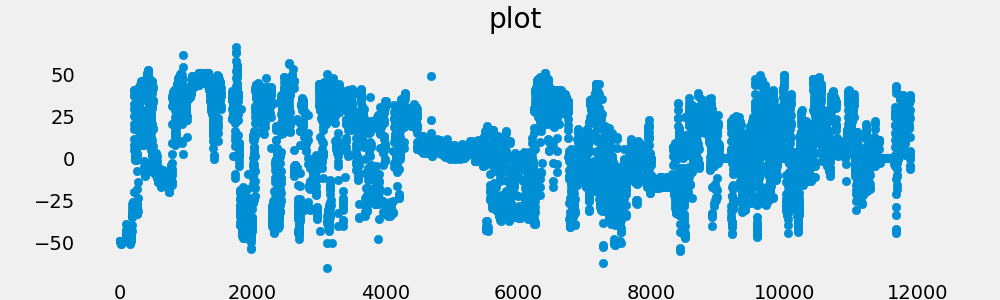

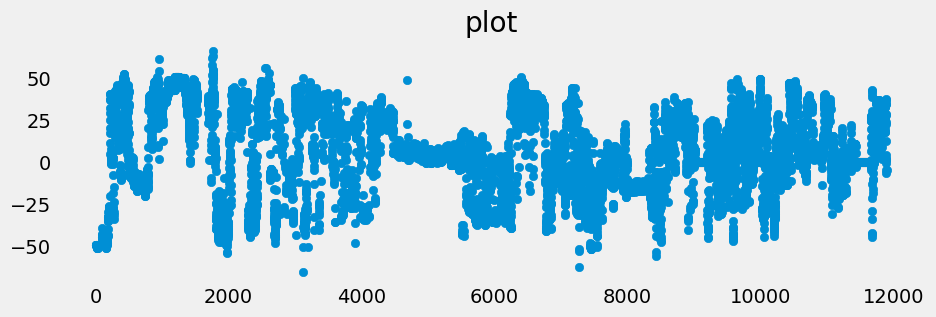

In [47]:
UNF.plot1d(np.arange(len(vec_head[:,0])),vec_head[:,0],title='plot')

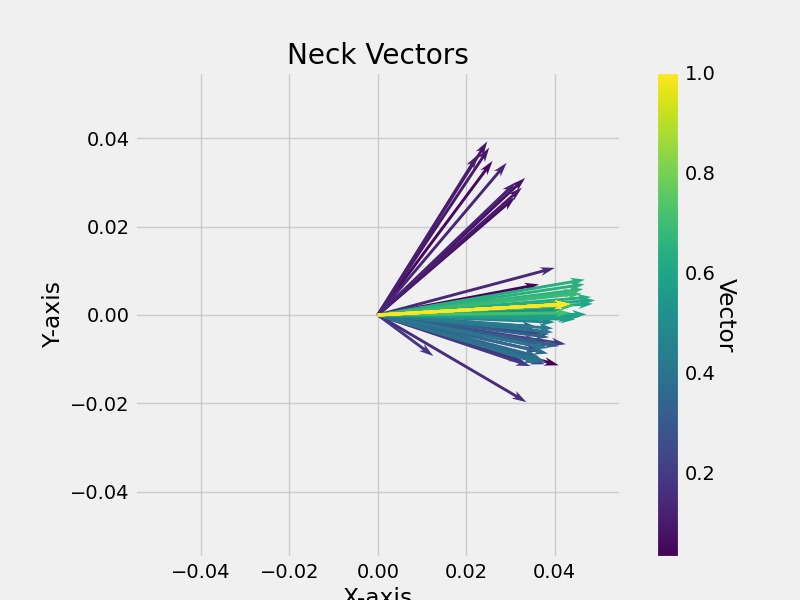

In [55]:
%matplotlib widget
import matplotlib.cm as cm
start = 1000
end = 1100
matrix = MegaData[d-1,start:end,49:51]/1000
origin = np.zeros((int(end-start), 2))
# Create a colormap (colors will range from 1 to 80)
colors = np.linspace(0, 1, int(end-start))  # Normalize the color values between 0 and 1
colormap = cm.get_cmap('viridis')  # Use 'viridis' or another colormap

# Plot the 2D vectors with corresponding colors
plt.figure(figsize=(8, 6))

quiver = plt.quiver(
    origin[:, 0], origin[:, 1], 
    matrix[:, 0], matrix[:, 1], 
    colors,  # Use normalized colors as the color value
    angles='xy', scale_units='xy', scale=1, 
    cmap=colormap, headwidth=3, headlength=5, headaxislength=4, linewidth=1
)
cbar = plt.colorbar(quiver)
cbar.set_label('Vector', rotation=270, labelpad=15)    

# Optionally add labels
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.title('Neck Vectors')
plt.gca().set_aspect('equal', adjustable='box')
plt.show()

# Define velocities and speeds uniformly and save in MegaData

change the first 3 lines according to the data

same goes for the first and second lines of the next two cells

In [56]:
#9, 3, 2 time point shift is used for computing velocity (3 and around 1.4 sec,0.3) for video 2and 3
#12, 4,2 time point shift is used for computing velocity (3 and around 1.4 sec,0.5) for video 1,4 and 5
#12, 4,2 time point shift is used for computing velocity (3 and around 1.4 sec,0.5) for video 4,5,6,7,8,9
dt = [2,4,12]
df_ext_coord = copy.deepcopy(extended80matrix[:,:])#if it is 2,4 and 5 keep [1:,1:]
fps = fps8

df_ext_coord_diff = (df_ext_coord[dt[0]:,:] - df_ext_coord[:-dt[0] ,:])/(dt[0]/fps)
df_ext_coord_diff7 = (df_ext_coord[dt[1]:,:] - df_ext_coord[:-dt[1],:])/(dt[1]/fps)
df_ext_coord_diff15 = (df_ext_coord[dt[2]:,:] - df_ext_coord[:-dt[2],:])/(dt[2]/fps)


df_x_mean_diff, df_y_mean_diff = UNF.compute_mean_everySec(df_ext_coord_diff[:,40:-40])
df_x_mean_diff7, df_y_mean_diff7 = UNF.compute_mean_everySec(df_ext_coord_diff7[:,40:-40])
df_x_mean_diff15, df_y_mean_diff15 = UNF.compute_mean_everySec(df_ext_coord_diff15[:,40:-40])

#The acceleration of the mean
a_x = (df_x_mean_diff7[dt[1]:] - df_x_mean_diff7[:-dt[1]])/(dt[1]/fps)
a_y = (df_y_mean_diff7[dt[1]:] - df_y_mean_diff7[:-dt[1]])/(dt[1]/fps)

v_head = np.zeros((len(df_ext_coord[:,0])-1,3)) # x and y coordinate of the head velocity
v_tail = np.zeros((len(df_ext_coord[:,0])-1,3)) 
v_head7 = np.zeros((len(df_ext_coord[:,0])-1,3)) # x and y coordinate of the head velocity
v_tail7 = np.zeros((len(df_ext_coord[:,0])-1,3))
v_head15= np.zeros((len(df_ext_coord[:,0])-1,3)) # x and y coordinate of the head velocity
v_tail15 = np.zeros((len(df_ext_coord[:,0])-1,3))

v_center = np.zeros((len(df_ext_coord[:,0])-1,3)) 
vec_center = np.zeros((len(df_ext_coord[:,0])-1,3)) # vector that shows the direction of body at each moment
vec_head = np.zeros((len(df_ext_coord[:,0])-1,3))
vec_tail = np.zeros((len(df_ext_coord[:,0])-1,3))
vec_neck = np.zeros((len(df_ext_coord[:,0])-1,3))
vec_headLateral = np.zeros((len(df_ext_coord[:,0])-1,3))
vec_tailLateral = np.zeros((len(df_ext_coord[:,0])-1,3))
vec_headVScenter = np.zeros((len(df_ext_coord[:,0])-1,1))
vec_headVSneck = np.zeros((len(df_ext_coord[:,0])-1,1))

v_center_signed = np.zeros((len(df_ext_coord[:,0])-1,3))
v_center_signed_2 = np.zeros((len(df_ext_coord[:,0])-1))
v_center_signed7 = np.zeros((len(df_ext_coord[:,0])-1,3))
v_center_signed7_2 = np.zeros((len(df_ext_coord[:,0])-1))
v_center7 = np.zeros((len(df_ext_coord[:,0])-1,3))
v_center_signed15 = np.zeros((len(df_ext_coord[:,0])-1,3))
v_center_signed15_2 = np.zeros((len(df_ext_coord[:,0])-1))

v_center15 = np.zeros((len(df_ext_coord[:,0])-1,3))
v_head_signed = np.zeros((len(df_ext_coord[:,0])-1,3))
v_head_signed7 = np.zeros((len(df_ext_coord[:,0])-1,3))
v_head_signed15 = np.zeros((len(df_ext_coord[:,0])-1,3))


v_headP_signed = np.zeros((len(df_ext_coord[:,0])-1,3))
v_headP_signed7 = np.zeros((len(df_ext_coord[:,0])-1,3))
v_headP_signed15 = np.zeros((len(df_ext_coord[:,0])-1,3))

v_tail_signed = np.zeros((len(df_ext_coord[:,0])-1,3))
v_tail_signed7 = np.zeros((len(df_ext_coord[:,0])-1,3))
v_tail_signed15 = np.zeros((len(df_ext_coord[:,0])-1,3))
# head velocity: average of the velocity of the first 3 point in units of length/time
theta = np.zeros((len(df_ext_coord[:,0])))
theta7 = np.zeros((len(df_ext_coord[:,0])))
theta15 = np.zeros((len(df_ext_coord[:,0])))


print(np.shape(v_center))

for t in range(len(v_head)):
    vec_center[t,:2] = -np.array([df_ext_coord[t,90]-df_ext_coord[t,70], df_ext_coord[t,91]-df_ext_coord[t,71]])
    vec_head[t,:2] = -np.array([df_ext_coord[t,20]-df_ext_coord[t,0],df_ext_coord[t,21]-df_ext_coord[t,1]])
    vec_tail[t,:2] = -np.array([df_ext_coord[t,158]-df_ext_coord[t,138],df_ext_coord[t,159]-df_ext_coord[t,139]])   
    vec_neck[t,:2] = -np.array([df_ext_coord[t,40]-df_ext_coord[t,20],df_ext_coord[t,41]-df_ext_coord[t,21]])
    
    vec_headLateral[t,:2] = UNF.compute_perpendicular_vector(vec_head[t,:2])
    vec_tailLateral[t,:2] = UNF.compute_perpendicular_vector(vec_tail[t,:2])
    vec_headVScenter[t,0] = UNF.cross_product_2d(vec_head[t,:2],vec_center[t,:2])/(np.linalg.norm(vec_head[t,:2])*np.linalg.norm(vec_center[t,:2]))
    vec_headVSneck[t,0] = UNF.cross_product_2d(vec_head[t,:2],vec_neck[t,:2])/(np.linalg.norm(vec_head[t,:2])*np.linalg.norm(vec_neck[t,:2]))

    if t > dt[0]-1:
        vcen_mean = [df_x_mean_diff[t-dt[0]], df_y_mean_diff[t-dt[0]]]
        v_head[t,:2] = [np.nanmean(df_ext_coord_diff[t-dt[0],:10:2]),np.nanmean(df_ext_coord_diff[t-dt[0],1:10:2])]
        v_tail[t,:2] = [np.nanmean(df_ext_coord_diff[t-dt[0],150:160:2]),np.nanmean(df_ext_coord_diff[t-dt[0],151:160:2])]
        v_center[t,:2] = [(df_ext_coord_diff[t-dt[0],80]),(df_ext_coord_diff[t-dt[0],81])]#76:86:2
        #magnitude of the velocities
        v_head[t,2] = np.linalg.norm(v_head[t,:2])
        v_tail[t,2] = np.linalg.norm(v_tail[t,:2])
        v_center[t,2] = np.linalg.norm(v_center[t,:2])
        v_center_signed[t,2] = np.dot(v_center[t,:2],vec_center[t-dt[0],:2])/np.linalg.norm(vec_center[t-dt[0],:2])   
        v_center_signed_2[t] = np.dot(vcen_mean,vec_center[t-dt[0],:2])/np.linalg.norm(vec_center[t-dt[0],:2])  
        
        v_head_signed[t,2] = np.dot(v_head[t,:2],vec_head[t-dt[0],:2])/np.linalg.norm(vec_head[t-dt[0],:2])
        v_headP_signed[t,2] = np.dot(v_head[t,:2],vec_headLateral[t-dt[0],:2])/np.linalg.norm(vec_headLateral[t-dt[0],:2])
        v_tail_signed[t,2] = np.dot(v_tail[t,:2],vec_tailLateral[t-dt[0],:2])/np.linalg.norm(vec_tailLateral[t-dt[0],:2])
        theta[t] = UNF.angle_between_twovec(vec_center[t,:2],vec_center[t-dt[0],:2])/(dt[0]/fps)
    if t > dt[1]-1:
        vcen_mean7 = [df_x_mean_diff7[t-dt[1]], df_y_mean_diff7[t-dt[1]]]
        v_center7[t,:2] = [(df_ext_coord_diff7[t-dt[1],80]),(df_ext_coord_diff7[t-dt[1],81])]
        v_center7[t,2] = np.linalg.norm(v_center7[t,:2])     
        v_center_signed7[t,2] = np.dot(v_center7[t,:2],vec_center[t-dt[1],:2])/np.linalg.norm(vec_center[t-dt[1],:2])
        v_center_signed7_2[t] = np.dot(vcen_mean7,vec_center[t-dt[1],:2])/np.linalg.norm(vec_center[t-dt[1],:2])
        
        v_head7[t,:2] = [np.nanmean(df_ext_coord_diff[t-dt[1],0:10:2]),np.nanmean(df_ext_coord_diff[t-dt[1],1:10:2])]
        v_tail7[t,:2] = [np.nanmean(df_ext_coord_diff[t-dt[1],150:160:2]),np.nanmean(df_ext_coord_diff[t-dt[1],151:160:2])]
        v_head7[t,2] = np.linalg.norm(v_head7[t,:2]) 
        v_tail7[t,2] = np.linalg.norm(v_tail7[t,:2]) 
        v_head_signed7[t,2] = np.dot(v_head7[t,:2],vec_head[t-dt[1],:2])/np.linalg.norm(vec_head[t-dt[1],:2])
        v_headP_signed7[t,2] = np.dot(v_head7[t,:2],vec_headLateral[t-dt[1],:2])/np.linalg.norm(vec_headLateral[t-dt[1],:2])
        v_tail_signed7[t,2] = np.dot(v_tail7[t,:2],vec_tailLateral[t-dt[1],:2])/np.linalg.norm(vec_tailLateral[t-dt[1],:2])
        theta7[t] = UNF.angle_between_twovec(vec_center[t,:2],vec_center[t-dt[1],:2])/(dt[1]/fps)
    if t > dt[2]-1:
        vcen_mean15 = [df_x_mean_diff15[t-dt[2]], df_y_mean_diff15[t-dt[2]]]
        v_center15[t,:2] = [(df_ext_coord_diff15[t-dt[2],80]),(df_ext_coord_diff15[t-dt[2],81])]#77:86:2
        v_center15[t,2] = np.linalg.norm(v_center15[t,:2])     
        v_center_signed15[t,2] = np.dot(v_center15[t,:2],vec_center[t-dt[2],:2])/np.linalg.norm(vec_center[t-dt[2],:2])  
        v_center_signed15_2[t] = np.dot(vcen_mean15,vec_center[t-dt[2],:2])/np.linalg.norm(vec_center[t-dt[2],:2])  
        
        v_head15[t,:2] = [np.nanmean(df_ext_coord_diff[t-dt[2],0:10:2]),np.nanmean(df_ext_coord_diff[t-dt[2],1:10:2])]
        v_tail15[t,:2] = [np.nanmean(df_ext_coord_diff[t-dt[2],150:160:2]),np.nanmean(df_ext_coord_diff[t-dt[2],151:160:2])]
        v_head15[t,2] = np.linalg.norm(v_head15[t,:2]) 
        v_tail15[t,2] = np.linalg.norm(v_tail15[t,:2]) 
        v_head_signed15[t,2] = np.dot(v_head15[t,:2],vec_head[t-dt[2],:2])/np.linalg.norm(vec_head[t-dt[2],:2])#it should be w.r.t. v_neck
        v_headP_signed15[t,2] = np.dot(v_head15[t,:2],vec_headLateral[t-dt[2],:2])/np.linalg.norm(vec_headLateral[t-dt[2],:2])
        v_tail_signed15[t,2] = np.dot(v_tail7[t,:2],vec_tailLateral[t-dt[2],:2])/np.linalg.norm(vec_tailLateral[t-dt[2],:2])
        theta15[t] = UNF.angle_between_twovec(vec_center[t,:2],vec_center[t-dt[2],:2])/(dt[2]/fps)



(11898, 3)
1.0000000000000002
1.0000000000000002
1.0000000000000002
1.0000000000000002
1.0000000000000002
1.0000000000000002
1.0000000000000002
1.0000000000000002
1.0000000000000002
1.0000000000000002
1.0000000000000002
1.0000000000000002
1.0000000000000002
1.0000000000000002
1.0000000000000002
1.0000000000000002
1.0000000000000002
1.0000000000000002
1.0000000000000002
1.0000000000000002
1.0000000000000002
1.0000000000000002
1.0000000000000002
1.0000000000000002
1.0000000000000002
1.0000000000000002
1.0000000000000002
1.0000000000000002
1.0000000000000002
1.0000000000000002
1.0000000000000002
1.0000000000000002
1.0000000000000002
1.0000000000000002
1.0000000000000002
1.0000000000000002
1.0000000000000002
1.0000000000000002
1.0000000000000002
1.0000000000000002
1.0000000000000002
1.0000000000000002
1.0000000000000002
1.0000000000000002
1.0000000000000002
1.0000000000000002
1.0000000000000002
1.0000000000000002
1.0000000000000002
1.0000000000000002
1.0000000000000002
1.0000000000000002
1

# Save the velocities

In [57]:
print(np.shape(df_ext_coord_diff[:,20:-20]))

(11897, 120)


In [58]:
#add head and tail velocity
d=9
indices = [int(i) for i in MegaData[d-1,:L[d-1],11]]
MegaData[d-1,:L[d-1],21] = v_head_signed[indices,2]
MegaData[d-1,:L[d-1],22] = v_head_signed7[indices,2]
MegaData[d-1,:L[d-1],23] = v_head_signed15[indices,2]
MegaData[d-1,:L[d-1],24] = v_head_signed[indices,2]
MegaData[d-1,:L[d-1],25] = v_head7[indices,2]
MegaData[d-1,:L[d-1],19] = v_head15[indices,2]
MegaData[d-1,:L[d-1],20] = v_tail15[indices,2]

MegaData[d-1,:L[d-1],29] = v_headP_signed[indices,2]
MegaData[d-1,:L[d-1],30] = v_headP_signed7[indices,2]
MegaData[d-1,:L[d-1],31] = v_headP_signed15[indices,2]

MegaData[d-1,:L[d-1],32] = v_tail_signed15[indices,2]
MegaData[d-1,:L[d-1],33] = v_tail_signed7[indices,2]
MegaData[d-1,:L[d-1],34] = v_tail_signed[indices,2]

MegaData[d-1,:L[d-1],37] = vec_headVScenter[indices,0]
MegaData[d-1,:L[d-1],38] = vec_headVSneck[indices,0]

In [59]:

pix = 100#pixel_size1
indices = [int(i) for i in MegaData[d-1,:L[d-1],11]]

MegaData[d-1,:L[d-1],15] = v_center7[indices,2]*pix/100
#MegaData[d-1,:L,:2] = v_center_signed[indices,2]
MegaData[d-1,:L[d-1],16]= v_center_signed7[indices,2]*pix/100
#MegaData[d-1,:L,:2] = v_head[indices,2]
#MegaData[d-1,:L,:2] = v_tail[indices,2]
MegaData[d-1,:L[d-1],13] = v_center15[indices,2]*pix/100
MegaData[d-1,:L[d-1],14] = v_center_signed15[indices,2]*pix/100
MegaData[d-1,:L[d-1],17] = v_center[indices,2]*pix/100
MegaData[d-1,:L[d-1],18] = v_center_signed[indices,2]*pix/100#shows the component of the velocity along body vector

MegaData[d-1,:L[d-1],41] = v_center_signed_2[indices]*pix/100
MegaData[d-1,:L[d-1],42] = v_center_signed7_2[indices]*pix/100
MegaData[d-1,:L[d-1],43] = v_center_signed15_2[indices]*pix/100

MegaData[d-1,:L[d-1],45] = theta[indices]
MegaData[d-1,:L[d-1],46] = theta7[indices]
MegaData[d-1,:L[d-1],47] = theta15[indices]


## save acceleration

In [60]:
#save acceleration
for t in range(2*dt[1],L[d-1]):
    print(a_y[t-2*dt[1]])
    MegaData[d-1,t,48] = np.linalg.norm([a_x[t-2*dt[1]],a_y[t-2*dt[1]]])

0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
-0.00028393287400731995
-0.009600790883133214
-0.11001580749802713
-0.390589713149614
-0.1786061910604502
0.35177806307810183
0.7005787281430315
1.2781055700440476
0.8926687666355526
0.010291991605532791
-0.17364516603592078
-0.38549973926777026
-0.22756114162481045
-0.014961330653903815
-0.2917768063022145
-0.4783525629352162
-0.48443377198226967
-0.337455795342602
-0.12514094830686914
-0.023663554691447077
-0.0017837290940150297
-5.213780399557777e-05
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
-2.1316282072803005e-15
nan
nan
0.5866703919451183
0.007554336508528792
nan
nan
nan
nan
nan
nan
nan
nan
nan
-7.125543534651164
nan
nan
nan
6.98192372826338
5.5560959534073735
3.639328461556624
0.27742217290044957
-4.620290911340616
-5.970385149296367
-4.6500258170410556
-1.619522718616846
1.17816507156287
2.10988

In [61]:
pix1 = 19.23/(10**4)#0401
pix2 = 20/(10**4)#0511
pix3 = 19.23/(10**4)#0807-1
pix4 = 19.23/(10**4)#0807-2 
pix5 = 22.22/(10**4)#0917 
pix6 = 19.6/(10**4)#0920 
pix7 = 18.5/(10**4)#0RIM 
pix8 = 16.6/(10**4)#AVA0319 
pix = [1,pix1,pix2,pix3,pix4,pix5,pix6,pix7,pix8]
pix

[1,
 0.001923,
 0.002,
 0.001923,
 0.001923,
 0.002222,
 0.00196,
 0.00185,
 0.0016600000000000002]

In [75]:
# correct units
d=7
for b in [13,14,15,16,17,18,19,20,21,22,23,24,25,29,30,31,32,33,34,41,42,43,49,50,51,52,53,54,55,56]:
    MegaData[d-1,:,b] = MegaData[d-1,:,b]*pix[d-1]/pix[5]

In [74]:
# correct units
d=8
for b in [13,14,15,16,17,18,19,20,21,22,23,24,25,29,30,31,32,33,34,41,42,43,49,50,51,52,53,54,55,56]:
    MegaData[d-1,:,b] = MegaData[d-1,:,b]*pix[d-1]



In [62]:
d=9
for b in [13,14,15,16,17,18,19,20,21,22,23,24,25,29,30,31,32,33,34,41,42,43,49,50,51,52,53,54,55,56]:
    MegaData[d-1,:,b] = MegaData[d-1,:,b]*pix[d-1]

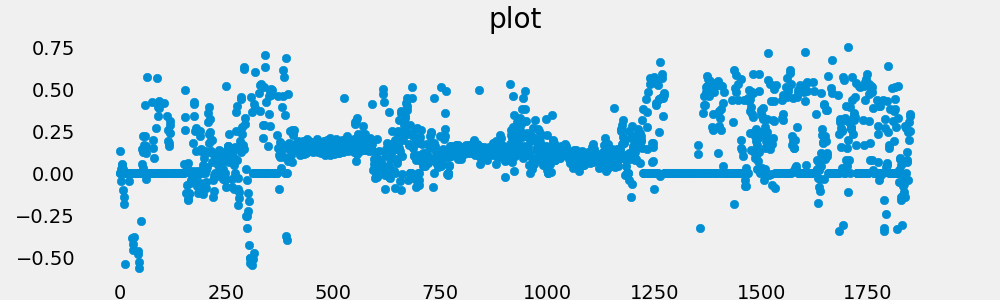

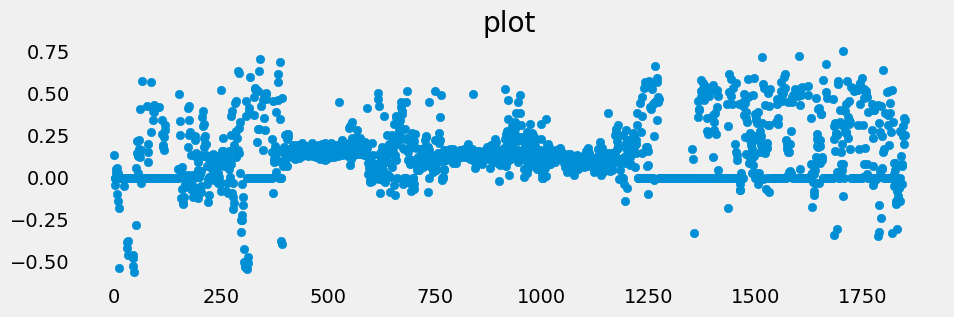

In [64]:
i=1
UNF.plot1d(np.arange(L9),MegaData[d-1,:L9,i],title='plot')

In [50]:
# worm 7
#[0,-0.098],[1,-0.04],[2,-0.07],[5,-0.06/0.4],[3,(0.4:3000,-0.016:900)],[4,(-0.05,1.25)],[5,(-0.055:4500)],[2,(-0,:3600)]
print(i)
start = 1500
end = 2000
indBad = (MegaData[d-1,start:end,i])<0
MegaData[d-1,start + np.nonzero(indBad)[0],i] = 0

0


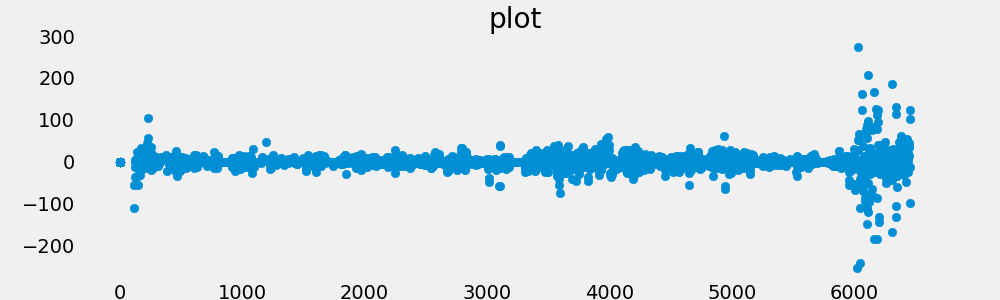

In [61]:
i = 42
UNF.plot1d(MegaData[d-1,:,11],MegaData[d-1,:,i],title='plot')

In [54]:
# worm 7
#[15,100],[16,-80],[16,100],[17,100],[18,110],[18,-100],[45,150],[46,120],[48,70],[13,50],[14,50/-50]
print(i)
start = 0
end = L8
indBad = (MegaData[d-1,start:end ,i])>100
MegaData[d-1,start + np.nonzero(indBad)[0],i] = np.nan

48


In [62]:
d = 8

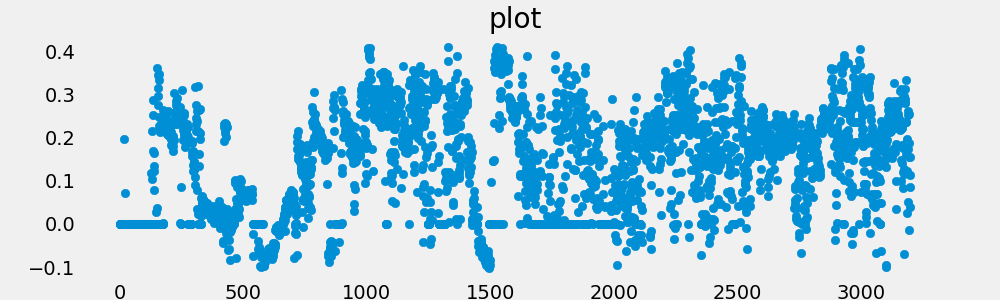

In [66]:

i = 0
UNF.plot1d(np.arange(L[d-1]),MegaData[d-1,:L[d-1],i],title='plot')

In [228]:
# worm 2
#[0,-0.14/0.4],[1,1],[2,0.4/-0.08],[5,-0.06/0.4],[3,(0.4:3000,-0.016:900)],[4,(-0.05,1.25)],[5,(-0.055:4500)],[2,(-0,:3600)]
print(i)
start = 4400
end = L6
indBad = (MegaData[d-1,start:end,i]) <-2
MegaData[d-1,start + np.nonzero(indBad)[0],i] = 0

4


4082.0


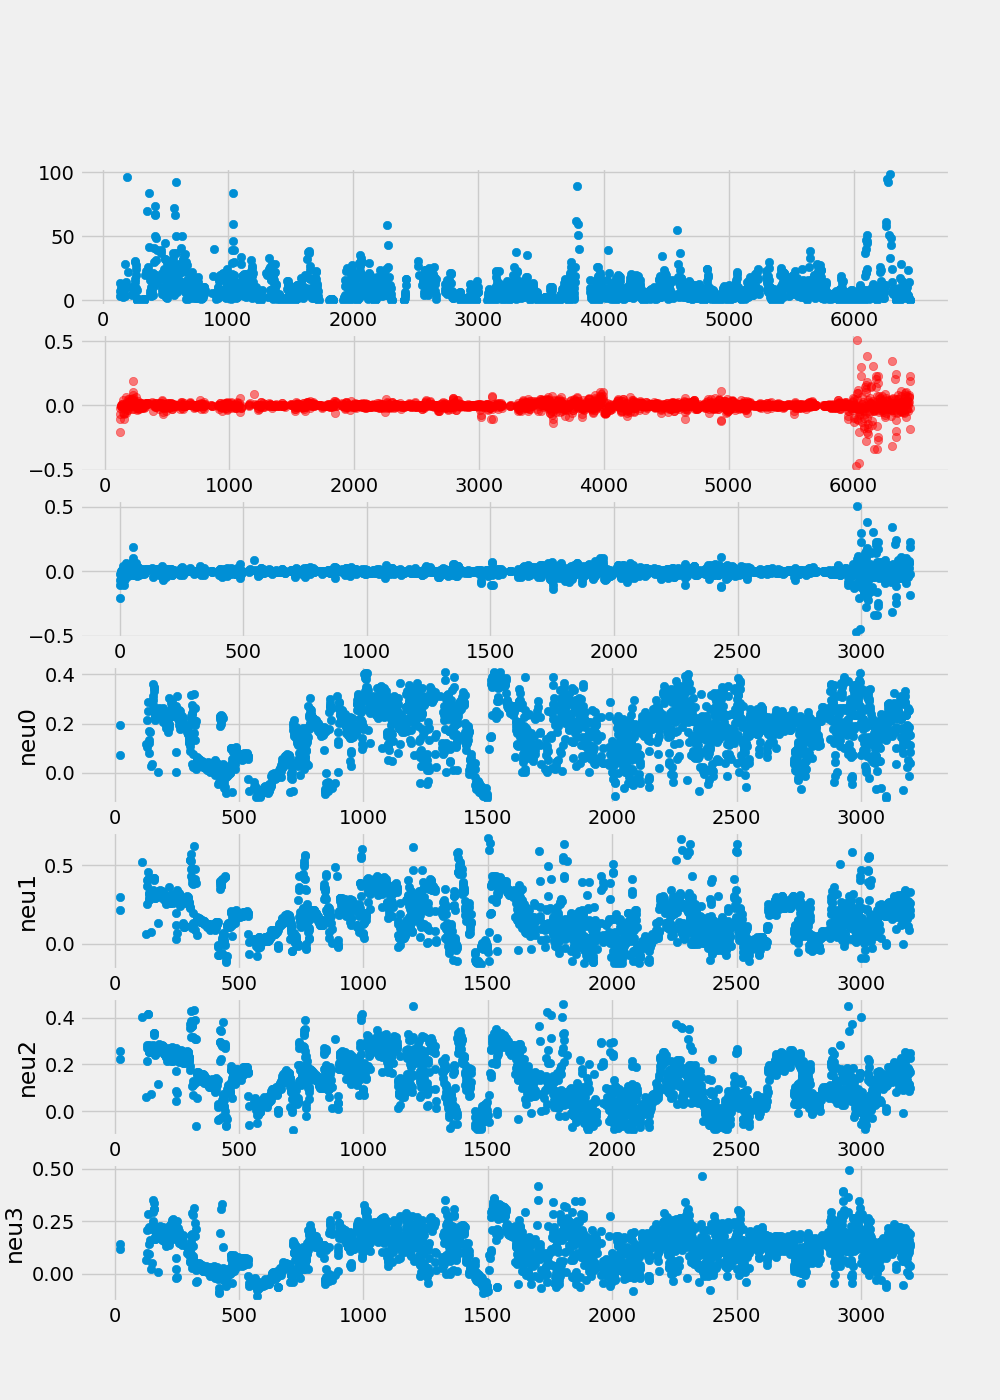

In [15]:
#plot one of the velocities
V0=42
V02 = 48
d=8
%matplotlib widget
fig = plt.figure(figsize=(10,14))
ax = fig.add_subplot(711)
ax2 = fig.add_subplot(712)
ax3 = fig.add_subplot(713)
ax4 = fig.add_subplot(714)
ax5 = fig.add_subplot(715)
ax6 = fig.add_subplot(716)
ax7 = fig.add_subplot(717)
MegaCopy = np.copy(MegaData)
'''
ind = np.abs(MegaCopy[d-1,:,V0-1])<13
print(ind)
MegaCopy[d-1,ind,15:19] = 0
MegaCopy[d-1,ind,15:19] = 0
'''
nonz1  = np.nonzero(MegaCopy[d-1,:L[d-1],V02])
ax.scatter(MegaCopy[d-1,nonz1[0],11],MegaCopy[d-1,nonz1[0],V02])
'''
nonz2  = np.nonzero(v_center_signed[:,2])
ax2.scatter(nonz2[0],v_center_signed[nonz2[0],2],color='r')
nonz2  = np.nonzero(v_center[:,2])
ax2.scatter(nonz2[0],v_center[nonz2[0],2],alpha=0.5)
'''
nonz2  = np.nonzero(MegaCopy[d-1,:L[d-1],V0-1])
#ax2.scatter(MegaCopy[d-1,nonz2[0],11],MegaCopy[d-1,nonz2[0],V0-1])
nonz2  = np.nonzero(MegaCopy[d-1,:L[d-1],V0-1])
ax2.scatter(MegaCopy[d-1,nonz2[0],11],MegaCopy[d-1,nonz2[0],V0],alpha=0.5,color='r')

nonz3  = np.nonzero(MegaCopy[d-1,:L[d-1],V0])
ax3.scatter(nonz3[0],MegaCopy[d-1,nonz3[0],V0])
#ax3.scatter(nonz3[0],MegaData[d-1,nonz3[0],10],color='g')
N=[0,1,2,3,4,5]
nonz4  = np.nonzero(MegaData[d-1,:L[d-1],N[0]])
ax4.scatter(nonz4[0],MegaData[d-1,nonz4[0],N[0]])
ax4.set_ylabel("neu"+str(N[0]))
nonz5  = np.nonzero(MegaData[d-1,:L[d-1],N[1]])
ax5.scatter(nonz5[0],MegaData[d-1,nonz5[0],N[1]])
ax5.set_ylabel("neu"+str(N[1]))

nonz6  = np.nonzero(MegaData[d-1,:L[d-1],N[2]])
ax6.scatter(nonz6[0],MegaData[d-1,nonz6[0],N[2]])
ax6.set_ylabel("neu"+str(N[2]))
nonz7 = np.nonzero(MegaData[d-1,:L[d-1],N[3]])
ax7.scatter(nonz7[0],MegaData[d-1,nonz7[0],N[3]])
ax7.set_ylabel("neu"+str(N[3]))
start,end = 2000,2200#1021,1182
start2,end2 = MegaData[d-1,start,11],MegaData[d-1,end,11]
print(start2)
'''
ax.set_ylim(top=50)
ax.set_ylim(bottom=-50)
ax2.set_ylim(top=50)
ax2.set_ylim(bottom=-50)
ax3.set_ylim(top=50)
ax3.set_ylim(bottom=-50)

ax.set_xlim(left=start2)
ax.set_xlim(right=end2)
ax2.set_xlim(left=start2)
ax2.set_xlim(right=end2)
ax3.set_xlim(left=start)
ax3.set_xlim(right=end)
ax4.set_xlim(left=start)
ax4.set_xlim(right=end)
ax5.set_xlim(left=start)
ax5.set_xlim(right=end)
ax6.set_xlim(left=start)
ax6.set_xlim(right=end)
ax7.set_xlim(left=start)
ax7.set_xlim(right=end)
'''
plt.show()

In [191]:
#correct velocities if needed

indBad = (MegaData[d-1,:,48])>54
MegaData[d-1,indBad,48] = 0
'''
MegaData[d-1,indBad,13:27] = 0
MegaData[d-1,indBad,29:36] = 0
MegaData[d-1,indBad,37:39] = 0
MegaData[d-1,indBad,41:44] = 0
MegaData[d-1,indBad,41:44] = 0
MegaData[d-1,indBad,45:48] = 0
'''
print(np.nonzero(indBad))

(array([2467, 3050, 3052, 3055]),)


(11899, 160)


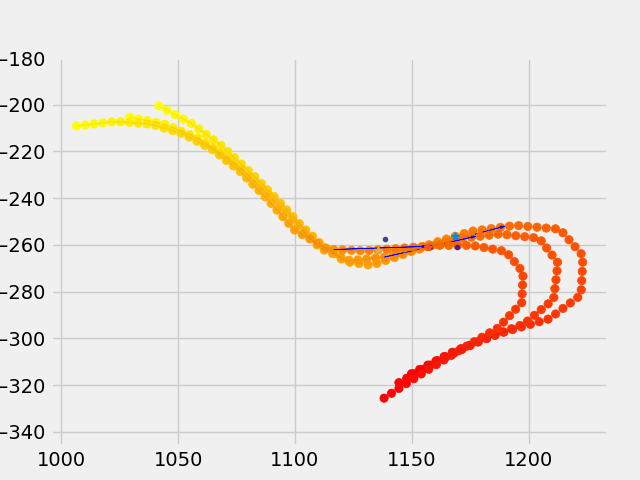

In [65]:
#plot posture
t_xy_v1_ext= np.copy(extended80matrix)#rowsArr_floatloc2[:,1:])
print(np.shape(t_xy_v1_ext))
style.use('fivethirtyeight')
# Plot the data points in 3D space with color-coded cluster assignments
fig = plt.figure()#figsize=(25,5)
ax = fig.add_subplot(111)
#ax.set_ylim(bottom=200)
#ax.set_ylim(top=600)
#Create a list of colors for each segment of the line
col = np.arange(80)+20
colors = cm.viridis(np.linspace(0, 1, 20))
count=0
for t in range(2400,2405):#np.shape(smoothed_arr)[0]):
    if np.sum(t_xy_v1_ext[t,:])>0:
        ax.plot(UNF.every_second_component(t_xy_v1_ext[t,:],1),UNF.every_second_component(-t_xy_v1_ext[t,:],0),lw=1,
                c='b',alpha=0.05)    
        ax.scatter(UNF.every_second_component(t_xy_v1_ext[t,:],1),UNF.every_second_component(-t_xy_v1_ext[t,:],0),
                       c=col,cmap='autumn')
        #ax.annotate(str(count),(np.nanmean(every_second_component(t_xy_v1_ext[t,66:96],1)),np.nanmean(every_second_component(-t_xy_v1_ext[t,67:96],0))),
        #           textcoords="offset points",  xytext=(1, 1),  ha='center')#,
        ax.plot((np.mean(t_xy_v1_ext[t,40:-40:2])),np.mean(-t_xy_v1_ext[t,41:-40:2]), '.',c = colors[np.mod(t,20)])
        #ax.annotate(str(count),(np.nanmean(t_xy_v1_ext[t,76:86:2]),np.nanmean(-t_xy_v1_ext[t,77:86:2])),
        #           textcoords="offset points",  xytext=(1, 1),  ha='center')
        ax.arrow(df_ext_coord[t,90], -df_ext_coord[t,91], vec_center[t,0], -vec_center[t,1], head_width=1, head_length=2, fc='b', ec='b')
                    #size=100,color='blue')
        ax.plot((t_xy_v1_ext[t,80]),-t_xy_v1_ext[t,81],'*',lw=4)
        count=count+1
ax.set_xlabel('x')

ax.set_ylabel('y')
ax.axis('equal')
plt.show()

In [151]:
#correct activities if needed
N=3
indBad = (MegaData[d-1,:,N]) <0.9
MegaData[d-1,indBad,N] = 0

In [91]:
#set outliers to zero
MegaData[d-1,:L[d-1],V0] = droptop5perc(dropbottom5perc((MegaData[d-1,:L[d-1],V0]),0.002),0.002)

In [36]:
tophigh= np.nonzero(MegaData[d-1,:L[d-1],V0]<-50)
MegaData[d-1,tophigh[0],V0] = np.zeros(len(tophigh[0]))

In [106]:
V0=37
d=5

In [107]:
MegaData[d-1,:L[d-1],V0] = -MegaData[d-1,:L[d-1],V0]

In [47]:
L=[L1,L2,L3,L4,L5]

[   0    1    2 ... 2753 2754 2755]


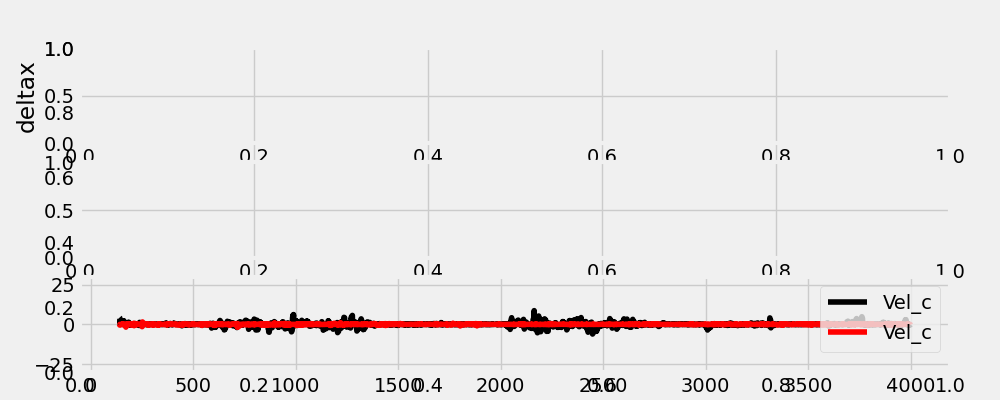

In [166]:
%matplotlib widget
fig, ax = plt.subplots(figsize=(10,4))
endtime=9000
# Plot the first vector
ax  = fig.add_subplot(311)
ax2  = fig.add_subplot(312)
ax3  = fig.add_subplot(313)

vel  = v_center_signed15[indices,2]
nonV =  np.nonzero(vel)[0]
print(nonV)
ax3.plot(MegaData[d-1,nonV ,11],-vel[nonV]*37/100, color='black', label='Vel_c')
ax3.plot(MegaData[d-1,nonV,11],MegaData[d-1,nonV,18], color='red', label='Vel_c')
ax.set_ylabel('deltax')

ax3.set_ylim(top=30)
ax3.set_ylim(bottom=-30)
ax3.legend()
plt.show()

In [95]:
rowsloc4,rowsArr_floatloc4 = extract_coordinates(Address4_loc ,num=1)

rowsloc5,rowsArr_floatloc5 = extract_coordinates(Address5_loc ,num=1)


(12193, 41)
(11458, 41)


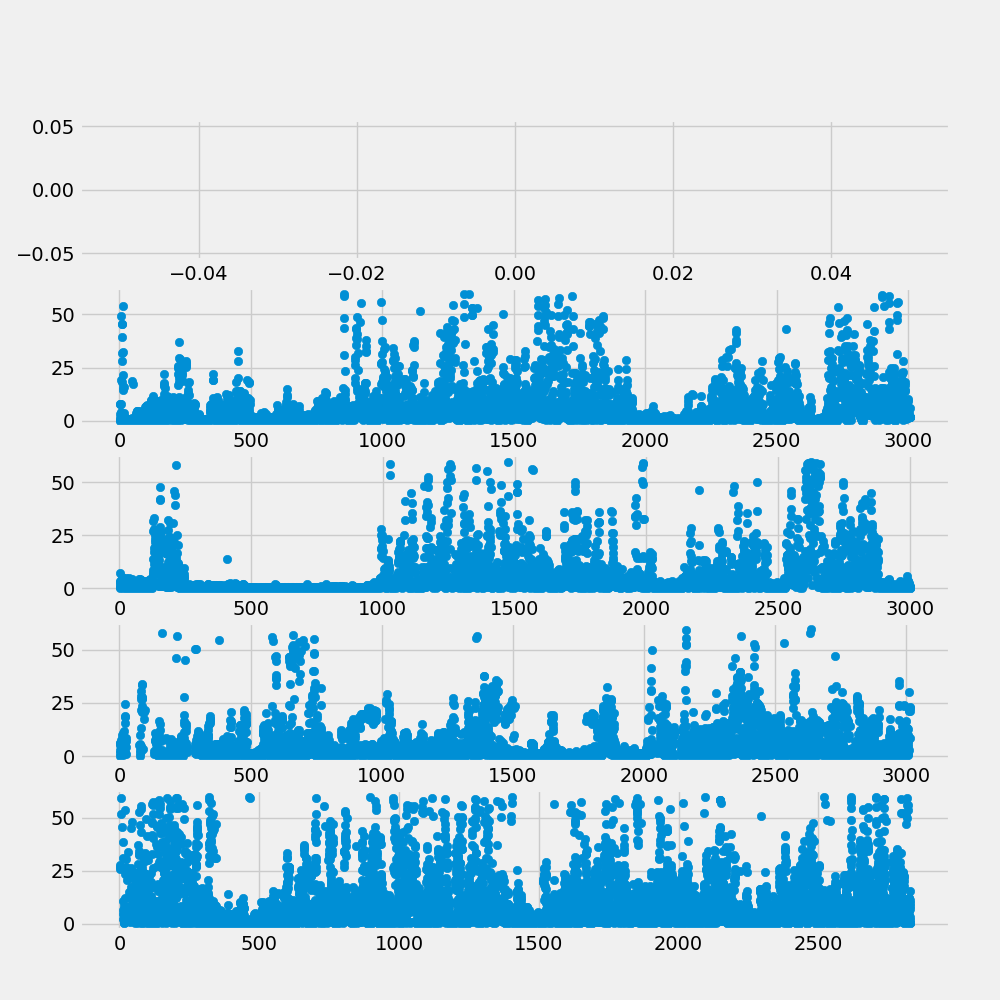

In [55]:
#angular velocity
%matplotlib widget

if True:
    if True:
        fig = plt.figure(figsize=(10,10))
        ax = fig.add_subplot(511)
        ax2 = fig.add_subplot(512)
        ax3 = fig.add_subplot(513)
        ax4 = fig.add_subplot(514)
        ax5 = fig.add_subplot(515)
        nonz1  = np.nonzero(theta_locam1)
        ax.scatter(MegaData[0,nonz1[0],12],theta_locam1[nonz1[0]])
        nonz2  = np.nonzero(theta_locam2)
        ax2.scatter(MegaData[1,nonz2[0],12],theta_locam2[nonz2[0]])
        nonz3  = np.nonzero(theta_locam3)
        ax3.scatter(MegaData[2,nonz3[0],12],theta_locam3[nonz3[0]])
        nonz4  = np.nonzero(theta_locam4)
        ax4.scatter(MegaData[3,nonz4[0],12],theta_locam4[nonz4[0]])
        nonz5  = np.nonzero(theta_locam5)
        ax5.scatter(MegaData[4,nonz5[0],12],theta_locam5[nonz5[0]])
 
    plt.show() 

# Save the h5 file here
        

In [109]:
hf.create_dataset('data/dataraw',data=MegaData)

<HDF5 dataset "dataraw": shape (5, 8100, 50), type "<f8">

13v_center_long,

14v_center_signed_long,15v_center_medium,16v_center_signed_medium,17v_center_short,18v_center_signed_short,
19v_head_long,20v_tail,

21: v_headsigned_short, 22 v_headsigned_medium, 23 v_headsigned_long, 24 v_head_short,25 v_head_medium, 26:head curvature,
27: mid-neurite, 28: mid-neurite,

29:head perpandicular_short, 30:head perpandicular_medium, 31:head perpandicular_long, 32:tail velocity perpendicular long, 33:tail velocity_medium, 34:tail velocity_short, 35: tail curvature, 36: merged neurites, 37:component of head vector perpandicular to the center vector. 38: component of a head vector parpendicular to the neck vector,39:nrV1,40:nrV2, 41,42,43:v_centermean_signed/7/15 computed differently. 44:bad frames in the upper camera. 45/46/47: mid body angular velocity theta short/medium/long

In [66]:
Dictionary = {'RIAL':0,'RIAR':1,'RIML':2,'RIMR':3,'RIBL':4,'RIBR':5,'sensory':6,
                                'nrDL':7, 'loopL':8, 'neuron':9,
                                'odor':10,'uppercamera_index':11,'lower_camera_time_stamp':12,'v_center_long':13,
                                'v_center_signed_long':14,'v_center_medium':15,
                                'v_center_signed_medium':16,'v_center_short':17,
                                'v_center_signed_short':18,'v_head_long':19,'v_tail':20,'v_head_short':21,
              'v_headsigned_medium':22, 'v_headsigned_long':23, 'v_head_short':24,'v_head_medium':25,
              'head_curvature':26, 'nrDR':27, 'loopR':28, 'head_perpandicular_short':29, 'head_perpandicular_medium':30,
              'head_perpandicular_long':31, 'tail_velocity_perpendicular_long':32,
              'tail_velocity_medium':33, 'tail_velocity_short':34, 'tail_curvature':35,'merged_neurite':36,
             'head_angle_wrt_center':37,'head_angle_wrt_neck':38,'nrVL':39,'nrVR':40,'v_com_short':41,'v_com_medium':42,
              'v_com_long':43,'bad fr in upper camera':44,'midbody_angular_velocity_short':45,'midbody_angular_velocity_medium':46,
             'midbody_angular_velocity_long':47,'head_Vector_x':49,'head_Vector_y':50,'neck_Vector_x':51,'neck_Vector_y':52,
              'center_Vector_x':53,'center_Vector_y':54,'center_position_x':55,'center_position_y':56}

In [68]:
hf = h5py.File('MegaData7_9worms_V0.h5', 'w')

In [ ]:
h5['data/dataraw'].attrs['variable_orders']= 'Dict'
h5['data/dataraw'].attrs.update(Dictionary)
h5['data/dataraw'].attrs.keys()

In [69]:
hf.create_dataset('data/dataraw',data=MegaData, compression="gzip", compression_opts=9)
hf['data/dataraw'].attrs['variable_orders']= 'Dict'
hf['data/dataraw'].attrs.update(Dictionary)
hf['data/dataraw'].attrs.keys()

hf.create_dataset('data_sets_info/lowercam_length',data=L)
hf.create_dataset('data_sets_info/pixel_length_micrometer',data=pix)
hf.close()

In [ ]:
del h5['data/dataraw']
h5.create_dataset('data/dataraw',data=MegaData,compression="gzip", compression_opts=9)
h5['data/dataraw'].attrs['variable_orders']= 'Dict'
h5['data/dataraw'].attrs.update(Dictionary)
h5['data/dataraw'].attrs.keys()
del h5['data_sets_info/lowercam_length']
h5.create_dataset('data_sets_info/lowercam_length',data=L)
h5.close()

In [117]:
L7 = 3780
L = [L1,L2,L3,L4,L5,L6,L7]
MegaData[6,L7:,:] = 0

In [121]:
hf  = h5py.File('MegaData7_7worms_V2.h5', 'r')
MegaDataF = hf['data/dataraw']
L = np.array(hf['data_sets_info/lowercam_length'])
print(L)
hf.close()

[2756 4297 4289 5739 8075 6400 3780]


MegaData7_copy3 is the file where velocities are computed with averaging and smoothing and the  outliers of velocity and activity are kicked out